In [1]:
import numpy as np
import pandas as pd

# Slim KG for Benchmark (Apr 14)

### Modifying gene-disease GEO data (irrelavant)

In [28]:
# irrelavant

df = pd.read_csv("/home/vmottaqi/kg/drug_data/gene-disease/edges_GEO_disease_gene_IA_new_final_4112025.csv", index_col=0)
df

,source,relation,target,standardized_value,sign,dataset,source_type,target_type
0,Eczema,increases expression of,PKP3,1.571547,1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
1,Eczema,increases expression of,SFPQ,1.747156,1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
2,Eczema,increases expression of,HMOX2,1.594428,1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
3,Eczema,increases expression of,MAP7D1,2.038568,1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
4,Eczema,increases expression of,ERLIN1,1.828282,1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
...,...,...,...,...,...,...,...,...
139795,Malignant tumor of pancreas,decreases expression of,EPS8L1,-1.324579,-1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
139796,Malignant tumor of pancreas,decreases expression of,RHOJ,-1.176439,-1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
139797,Malignant tumor of pancreas,decreases expression of,SLC38A10,-1.179299,-1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
139798,Malignant tumor of pancreas,decreases expression of,PPP1R12A,-1.377895,-1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene


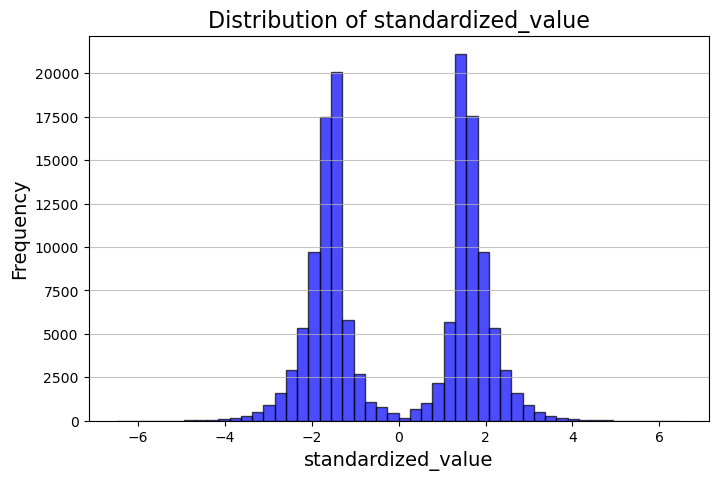

In [23]:
import matplotlib.pyplot as plt

# Plot the distribution of the 'standardized_value' column
plt.figure(figsize=(8, 5))
plt.hist(df['standardized_value'].dropna(), bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of standardized_value', fontsize=16)
plt.xlabel('standardized_value', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()

In [14]:
print(df['source'].nunique())
print(df['target'].nunique())

163
18516


In [29]:
import numpy as np

# Step 1: Swap the 'source' and 'target' columns.
df['temp'] = df['source']
df['source'] = df['target']
df['target'] = df['temp']
df.drop(columns='temp', inplace=True)

# Step 2: Swap the 'source_type' and 'target_type' columns.
df['temp'] = df['source_type']
df['source_type'] = df['target_type']
df['target_type'] = df['temp']
df.drop(columns='temp', inplace=True)

# Step 3: Rename "standardized_value" to "original_weight".
df.rename(columns={'standardized_value': 'original_weight'}, inplace=True)

# Step 4: Add new columns: 'new_weights' as NaN and override 'dataset' with "GEO".
df['new_weights'] = np.nan
# df['dataset'] = "GEO"  # Overriding any previous value.

# Step 5: Update the relation column:
#         Replace "increases expression of" → "upregulated in" and 
#         "decreases expression of" → "downregulated in".
df['relation'] = df['relation'].str.strip().str.lower()
df['relation'] = df['relation'].replace({
    'increases expression of': 'upregulated in',
    'decreases expression of': 'downregulated in'
})

# Step 6: Filter rows where original_weight > 2 or original_weight < -2.
df_final = df[(df['original_weight'] > 1) | (df['original_weight'] < -1)].copy()

# Optional: Reorder columns to match your KG format.
kg_columns = ['source', 'relation', 'target', 'original_weight', 'sign', 'source_type', 'target_type', 'dataset', 'new_weights']
df_final = df_final[kg_columns]

df_final


,source,relation,target,original_weight,sign,source_type,target_type,dataset,new_weights
0,PKP3,upregulated in,Eczema,1.571547,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
1,SFPQ,upregulated in,Eczema,1.747156,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
2,HMOX2,upregulated in,Eczema,1.594428,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
3,MAP7D1,upregulated in,Eczema,2.038568,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
4,ERLIN1,upregulated in,Eczema,1.828282,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
...,...,...,...,...,...,...,...,...,...
139795,EPS8L1,downregulated in,Malignant tumor of pancreas,-1.324579,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
139796,RHOJ,downregulated in,Malignant tumor of pancreas,-1.176439,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
139797,SLC38A10,downregulated in,Malignant tumor of pancreas,-1.179299,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
139798,PPP1R12A,downregulated in,Malignant tumor of pancreas,-1.377895,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN


In [30]:
print(df_final['source'].nunique())
print(df_final['target'].nunique())

18409
163


In [31]:
df_final.to_csv("/home/vmottaqi/kg/drug_data/gene-disease/edges_GEO_disease_gene_IA_new_final_Apr14.csv", index=False)

## Checkings

In [2]:
import pandas as pd
kg = pd.read_csv("/home/vmottaqi/kg/kg_versions/KG_edges_Vincent_slim_Mar282025.csv")
kg

/tmp/ipykernel_1512991/50549846.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv("/home/vmottaqi/kg/kg_versions/KG_edges_Vincent_slim_Mar282025.csv")


,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,100000085.0,causes,ABDOMINAL PAIN,0.21,-1.0,Chemical,Disease,SIDEr,0.21
1,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.21,-1.0,Chemical,Disease,SIDEr,0.21
2,100000085.0,causes,ABDOMINAL PAIN,0.05,-1.0,Chemical,Disease,SIDEr,0.05
3,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.05,-1.0,Chemical,Disease,SIDEr,0.05
4,100000085.0,causes,ABDOMINAL PAIN,0.06,-1.0,Chemical,Disease,SIDEr,0.06
...,...,...,...,...,...,...,...,...,...
6074727,CES1,has disease,COLONIC NEOPLASMS,NaN,0.0,Gene,Disease,PharmKG,NaN
6074728,CES1,has disease,CHRONIC HEPATITIS C INFECTION,NaN,0.0,Gene,Disease,PharmKG,NaN
6074729,CES1,has disease,STROKE DISORDER,NaN,0.0,Gene,Disease,PharmKG,NaN
6074730,F12,has disease,DEATH,NaN,0.0,Gene,Disease,PharmKG,NaN


In [3]:
print(kg['dataset'].unique())

['SIDEr' 'nSIDES' 'BioGPS Cell Line Gene Expression Profiles'
 'GDSC Cell Line Gene Expression Profiles'
 'Heiser et al., PNAS, 2011 Cell Line Gene Expression Profiles'
 'HPA Cell Line Gene Expression Profiles'
 'Klijn et al., Nat. Biotechnol., 2015 Cell Line Gene Expression Profiles'
 'CCLE Cell Line Gene Expression Profiles' 'PrimeKG'
 'CMAP Signatures of Differentially Expressed Genes for Small Molecules'
 'DepMap' 'Roadmap Epigenomics Cell and Tissue Gene Expression Profiles'
 'IUPHAR merged with Stitch'
 'BioGPS Human Cell Type and Tissue Gene Expression Profiles'
 'CCLE Proteomics' 'repoDB (unmtid-shinyapps.net)' 'UniProtKB' 'clue.io'
 'PharmacoDB Cell viability' 'CTD Gene-Disease Associations'
 'DISEASES Curated Gene-Disease Assocation Evidence Scores'
 'GAD Gene-Disease Associations'
 'PhosphoSitePlus Phosphosite-Disease Associations'
 'HPO Gene-Disease Associations' 'OMIM Gene-Disease Associations'
 'HuGE Navigator Gene-Phenotype Associations' 'PharmKG']


In [5]:
# Filter out rows where the 'dataset' column has the value 'PrimeKG'
df1_filtered = kg[kg['dataset'] = 'PrimeKG']

primekg = pd.read_csv("/home/vmottaqi/kg/drug_data/PrimeKG_chemical_disease_Apr92025.csv")
# Merge the filtered first DataFrame with the second DataFrame
df = pd.concat([df1_filtered, primekg], ignore_index=True)

# Display the merged DataFrame
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
2827131,59227,causes,HYPERTENSION,NaN,-1.0,Chemical,Disease,PrimeKG,NaN
2827132,134715568,treats,HYPERTENSION,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2827133,13791,causes,HYPERTENSION,NaN,-1.0,Chemical,Disease,PrimeKG,NaN
2827134,4756,causes,HYPERTENSION,NaN,-1.0,Chemical,Disease,PrimeKG,NaN
2827135,7172,causes,HYPERTENSION,NaN,-1.0,Chemical,Disease,PrimeKG,NaN
...,...,...,...,...,...,...,...,...,...
2860397,115355.0,treats,"TYROSINEMIA, TYPE I",NaN,1.0,Chemical,Disease,PrimeKG,NaN
2860398,25151352.0,treats,TENOSYNOVIAL GIANT CELL TUMOR,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2860399,25151352.0,treats,PIGMENTED VILLONODULAR SYNOVITIS,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2860400,5284583.0,causes,DEPERSONALIZATION DISORDER,NaN,-1.0,Chemical,Disease,PrimeKG,NaN


In [19]:

# primekg.head()

In [20]:
df.shape

(6111075, 9)

Stats

In [6]:
import pandas as pd

main_df = kg

# Assume main_df is your knowledge graph dataframe.

# ---------------------------
# 1. Total number of unique nodes
# ---------------------------
unique_nodes = set(main_df['source'].unique()).union(set(main_df['target'].unique()))
total_unique_nodes = len(unique_nodes)
print("Total unique nodes:", total_unique_nodes)

# ---------------------------
# 2. Unique nodes per entity type
# ---------------------------
# Get the union of all entity types from source_type and target_type
entity_types = set(main_df['source_type'].unique()).union(set(main_df['target_type'].unique()))

entity_node_counts = {}
for etype in entity_types:
    # For each type, get nodes appearing as source with that type and as target with that type
    nodes_from_source = set(main_df.loc[main_df['source_type'] == etype, 'source'].unique())
    nodes_from_target = set(main_df.loc[main_df['target_type'] == etype, 'target'].unique())
    total_nodes = nodes_from_source.union(nodes_from_target)
    entity_node_counts[etype] = len(total_nodes)

print("\nUnique nodes per entity type:")
for etype, count in entity_node_counts.items():
    print(f"  {etype}: {count}")

# ---------------------------
# 3. Unique relations and total edge counts for each entity pair
# ---------------------------
# Group by source_type, target_type, and relation, and count the number of edges.
relation_counts = (
    main_df.groupby(['source_type', 'target_type', 'relation'])
    .size()
    .reset_index(name='edge_count')
)

print("\nUnique relations and total edge counts for each entity pair:")
print(relation_counts)

# Optionally, group by entity pair and print the relation details in a structured format.
entity_pair_relations = {}
for (src_type, tgt_type), group in relation_counts.groupby(['source_type', 'target_type']):
    entity_pair_relations[(src_type, tgt_type)] = group[['relation', 'edge_count']].to_dict('records')

print("\nEntity pair relations:")
for pair, rels in entity_pair_relations.items():
    print(f"  {pair}:")
    for r in rels:
        print(f"    Relation: {r['relation']}, Edge count: {r['edge_count']}")


Total unique nodes: 82235

Unique nodes per entity type:
  Chemical: 18314
  Protein: 18664
  Disease: 16590
  Gene: 24348
  Cell Line: 4351

Unique relations and total edge counts for each entity pair:
   source_type target_type                 relation  edge_count
0    Cell Line     Disease          associates with        2568
1     Chemical   Cell Line               sensitizes      145629
2     Chemical     Disease                   causes      724527
3     Chemical     Disease                   treats       15050
4     Chemical        Gene  decreases expression of      455053
5     Chemical        Gene  increases expression of      463052
6     Chemical     Protein                activates        7727
7     Chemical     Protein                 inhibits        8374
8         Gene   Cell Line        over-expressed in     1865502
9         Gene   Cell Line       under-expressed in     1079606
10        Gene     Disease              has disease      787419
11        Gene     Protein   

In [7]:
# Group by source_type and target_type and aggregate the relation and edge_count into a list of dictionaries.
# Group by source_type and target_type and aggregate the relations into a dictionary.
relation_dict_df = (
    relation_counts.groupby(['source_type', 'target_type'])
    .apply(lambda group: {row['relation']: row['edge_count'] for _, row in group.iterrows()})
    .reset_index(name='relations')
)

relation_dict_df

,source_type,target_type,relations
0,Cell Line,Disease,{'associates with': 2568}
1,Chemical,Cell Line,{'sensitizes': 145629}
2,Chemical,Disease,"{'causes': 724527, 'treats': 15050}"
3,Chemical,Gene,"{'decreases expression of': 455053, 'increases..."
4,Chemical,Protein,"{'activates': 7727, 'inhibits': 8374}"
5,Gene,Cell Line,"{'over-expressed in': 1865502, 'under-expresse..."
6,Gene,Disease,{'has disease': 787419}
7,Gene,Protein,{'encodes': 20215}
8,Protein,Cell Line,"{'over-expressed in': 357640, 'under-expressed..."


Revisions of nodes and edges

In [2]:
df = kg
kg.shape

(6074732, 9)

In [31]:
import pandas as pd

# Assume df is your master Knowledge Graph DataFrame.

# 1. Identify all chemical nodes. We assume chemicals are marked in the 'source' column when source_type is "Chemical".
all_chemicals = set(kg.loc[kg["source_type"] == "Chemical", "source"].unique())

# 2. Identify chemical nodes that have a direct edge to any disease node.
chemicals_with_disease_edge = set(
    kg.loc[(kg["source_type"] == "Chemical") & (kg["target_type"] == "Disease"), "source"].unique()
)

# 3. Determine chemicals with no direct edge to any disease node.
chemicals_without_disease_edge = all_chemicals - chemicals_with_disease_edge

# Print the result.
print("Number of chemical nodes with no direct edge to any disease node:", len(chemicals_without_disease_edge))


Number of chemical nodes with no direct edge to any disease node: 13042


In [47]:
# Filter the dataframe for rows where source_type is 'Chemical' and target_type is 'Disease'
# chemical_disease_df_c = kg[(kg['source_type'] == 'Chemical') & (kg['target_type'] == 'Disease')& (kg['relation'] == 'causes')& (kg['dataset'] == 'PrimeKG')]
# chemical_disease_df_t = kg[(kg['source_type'] == 'Chemical') & (kg['target_type'] == 'Disease')& (kg['relation'] == 'treats') & (kg['dataset'] == 'PrimeKG')]

# # Get the unique number of chemicals in the source column
# unique_chemicals_t = chemical_disease_df_t['source'].nunique()
# unique_chemicals_c = chemical_disease_df_c['source'].nunique()

# print(f"Unique number of chemicals in the treat column: {unique_chemicals_t}")
# print(f"Unique number of chemicals in the cause column: {unique_chemicals_c}")

# # Find the intersection of chemicals in both dataframes
# common_chemicals = set(chemical_disease_df_c['source']).intersection(set(chemical_disease_df_t['source']))

# print(f"Number of chemicals present in both: {len(common_chemicals)}")
# print("Chemicals present in both:")
# print(common_chemicals)


Unique number of chemicals in the treat column: 2048
Unique number of chemicals in the cause column: 2259
Number of chemicals present in both: 1237
Chemicals present in both:
{'6917.0', '444036', '2519', '3158', '26987', '9906855.0', '5665.0', '59768', '56339', '5280793', '54675783', '5320', '6116.0', '4761', '5311066.0', '9651.0', '6291.0', '60871', '5339.0', '123600.0', '54675779.0', '36462.0', '2088.0', '1110.0', '73416022.0', '4011', '441140', '443879.0', '1775', '2733526', '10007', '24011.0', '1983', '441074', '54454.0', '444025.0', '5362129.0', '3305', '6099', '9941379.0', '135398745', '5311412.0', '146037278', '150311', '6167.0', '5852.0', '10531', '5744.0', '2554', '892', '3348.0', '243', '3385.0', '5834.0', '68873', '5282452.0', '6099959', '6445540.0', '6918462.0', '4567.0', '2771.0', '2955.0', '5161', '16666.0', '135398658.0', '4583', '10630', '137', '10324367', '5910', '176870.0', '1046', '5282226.0', '6674.0', '2710', '59768.0', '444', '23897.0', '12986439.0', '3825', '6083

In [38]:
# in PrimeKG
chemical_disease_df1 = kg[(kg['dataset'] == 'PrimeKG') & (kg['relation'] == 'treats')]
# print(chemical_disease_df1['target_type'].unique())
chemical_disease_df1

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
2827132,134715568,treats,HYPERTENSION,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2827148,5464343,treats,HYPERTENSION,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2827150,56330,treats,HYPERTENSION,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2827151,2162,treats,HYPERTENSION,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2827153,5484727,treats,HYPERTENSION,NaN,1.0,Chemical,Disease,PrimeKG,NaN
...,...,...,...,...,...,...,...,...,...
2860390,2733526.0,treats,"CARCINOMA, DUCTAL, BREAST",NaN,1.0,Chemical,Disease,PrimeKG,NaN
2860397,115355.0,treats,"TYROSINEMIA, TYPE I",NaN,1.0,Chemical,Disease,PrimeKG,NaN
2860398,25151352.0,treats,TENOSYNOVIAL GIANT CELL TUMOR,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2860399,25151352.0,treats,PIGMENTED VILLONODULAR SYNOVITIS,NaN,1.0,Chemical,Disease,PrimeKG,NaN


In [45]:
chemical_disease_df_t.shape

(7392, 9)

In [ ]:
Number of chemicals present in both: 1475

In [5]:
# Filter rows where 'source_type' is 'Protein' and 'target_type' is 'Cell Line'
protein_to_cell_line_df = df[(df['source_type'] == 'Gene') & (df['target_type'] == 'Disease')]

# Display the filtered dataframe
protein_to_cell_line_df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
5287313,SLC29A3,has disease,HISTIOCYTOSIS WITH JOINT CONTRACTURES AND SENS...,2.880087,0.0,Gene,Disease,CTD Gene-Disease Associations,NaN
5287314,SLC29A3,has disease,"HISTIOCYTOSIS, SINUS",2.880087,0.0,Gene,Disease,CTD Gene-Disease Associations,NaN
5287315,SLC29A3,has disease,LANGERHANS CELL HISTIOCYTOSIS,2.880087,0.0,Gene,Disease,CTD Gene-Disease Associations,NaN
5287316,SLC29A3,has disease,HYPERTRICHOSIS (DISEASE),2.880087,0.0,Gene,Disease,CTD Gene-Disease Associations,NaN
5287317,RPL27A,has disease,SKIN HYPERPIGMENTATION,2.880087,0.0,Gene,Disease,CTD Gene-Disease Associations,NaN
...,...,...,...,...,...,...,...,...,...
6074727,CES1,has disease,COLONIC NEOPLASMS,NaN,0.0,Gene,Disease,PharmKG,NaN
6074728,CES1,has disease,CHRONIC HEPATITIS C INFECTION,NaN,0.0,Gene,Disease,PharmKG,NaN
6074729,CES1,has disease,STROKE DISORDER,NaN,0.0,Gene,Disease,PharmKG,NaN
6074730,F12,has disease,DEATH,NaN,0.0,Gene,Disease,PharmKG,NaN


In [41]:
print(protein_to_cell_line_df['dataset'].unique())

['CTD Gene-Disease Associations'
 'DISEASES Curated Gene-Disease Assocation Evidence Scores'
 'GAD Gene-Disease Associations'
 'PhosphoSitePlus Phosphosite-Disease Associations'
 'HPO Gene-Disease Associations' 'OMIM Gene-Disease Associations'
 'HuGE Navigator Gene-Phenotype Associations' 'PharmKG']


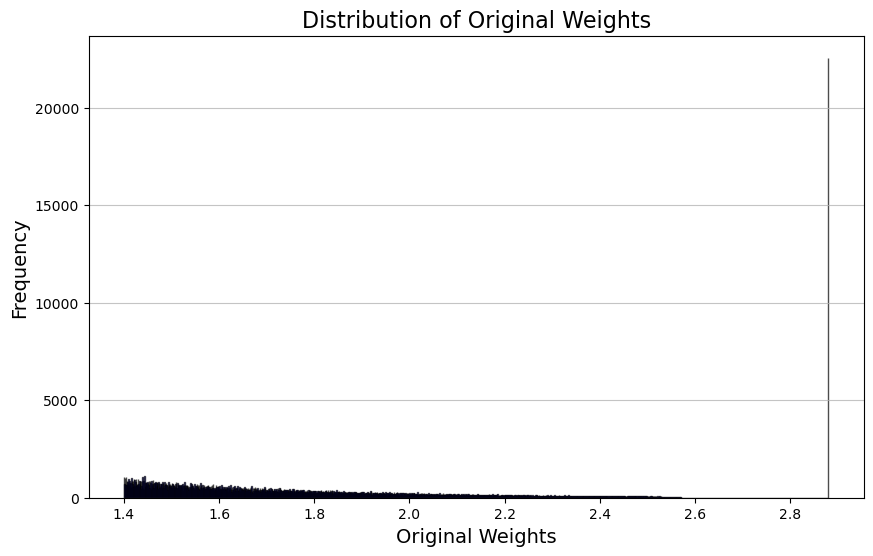

In [6]:
import matplotlib.pyplot as plt

# Drop NaN values from the 'original_weights' column
weights = protein_to_cell_line_df['original_weights'].dropna()

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(weights, bins=1530, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of Original Weights', fontsize=16)
plt.xlabel('Original Weights', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()

## Step 1. reducing edges and integrating data

In [2]:
import pandas as pd
kg = pd.read_csv("/home/vmottaqi/kg/kg_versions/KG_edges_Vincent_slim_Mar282025.csv")
kg

/tmp/ipykernel_2707955/50549846.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv("/home/vmottaqi/kg/kg_versions/KG_edges_Vincent_slim_Mar282025.csv")


,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,100000085.0,causes,ABDOMINAL PAIN,0.21,-1.0,Chemical,Disease,SIDEr,0.21
1,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.21,-1.0,Chemical,Disease,SIDEr,0.21
2,100000085.0,causes,ABDOMINAL PAIN,0.05,-1.0,Chemical,Disease,SIDEr,0.05
3,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.05,-1.0,Chemical,Disease,SIDEr,0.05
4,100000085.0,causes,ABDOMINAL PAIN,0.06,-1.0,Chemical,Disease,SIDEr,0.06
...,...,...,...,...,...,...,...,...,...
6074727,CES1,has disease,COLONIC NEOPLASMS,NaN,0.0,Gene,Disease,PharmKG,NaN
6074728,CES1,has disease,CHRONIC HEPATITIS C INFECTION,NaN,0.0,Gene,Disease,PharmKG,NaN
6074729,CES1,has disease,STROKE DISORDER,NaN,0.0,Gene,Disease,PharmKG,NaN
6074730,F12,has disease,DEATH,NaN,0.0,Gene,Disease,PharmKG,NaN


In [ ]:
print(kg['dataset'].unique())

NameError: name 'kg' is not defined

In [ ]:
# STEP 1: Filter out rows where the 'dataset' column has the value 'PrimeKG'

In [3]:
# Filter out rows where the 'dataset' column has the value 'PrimeKG'
df1_filtered = kg[kg['dataset'] != 'PrimeKG']

primekg = pd.read_csv("/home/vmottaqi/kg/drug_data/primekg/PrimeKG_chemical_disease_Apr92025.csv")
# Merge the filtered first DataFrame with the second DataFrame
df = pd.concat([df1_filtered, primekg], ignore_index=True)

# Display the merged DataFrame
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,100000085.0,causes,ABDOMINAL PAIN,0.21,-1.0,Chemical,Disease,SIDEr,0.21
1,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.21,-1.0,Chemical,Disease,SIDEr,0.21
2,100000085.0,causes,ABDOMINAL PAIN,0.05,-1.0,Chemical,Disease,SIDEr,0.05
3,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.05,-1.0,Chemical,Disease,SIDEr,0.05
4,100000085.0,causes,ABDOMINAL PAIN,0.06,-1.0,Chemical,Disease,SIDEr,0.06
...,...,...,...,...,...,...,...,...,...
6111070,445643.0,causes,POLYNEUROPATHY,NaN,-1.0,Chemical,Disease,PrimeKG_contraindication,NaN
6111071,445643.0,causes,NERVOUS SYSTEM DISEASES,NaN,-1.0,Chemical,Disease,PrimeKG_contraindication,NaN
6111072,16134395.0,causes,POLYNEUROPATHY,NaN,-1.0,Chemical,Disease,PrimeKG_contraindication,NaN
6111073,16134395.0,causes,NERVOUS SYSTEM DISEASES,NaN,-1.0,Chemical,Disease,PrimeKG_contraindication,NaN


In [14]:
# add chemical-chemical similarity
df_chem_chem = pd.read_csv("/home/vmottaqi/kg/drug_data/chem_chem_similairty_reliable_Apr112025.csv")
df = pd.concat([df, df_chem_chem], ignore_index=True)
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,100000085.0,causes,ABDOMINAL PAIN,0.21,-1.0,Chemical,Disease,SIDEr,0.21
1,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.21,-1.0,Chemical,Disease,SIDEr,0.21
2,100000085.0,causes,ABDOMINAL PAIN,0.05,-1.0,Chemical,Disease,SIDEr,0.05
3,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.05,-1.0,Chemical,Disease,SIDEr,0.05
4,100000085.0,causes,ABDOMINAL PAIN,0.06,-1.0,Chemical,Disease,SIDEr,0.06
...,...,...,...,...,...,...,...,...,...
6497385,44487032.0,is similar to,44485039.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00
6497386,44487032.0,is similar to,44487024.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00
6497387,44485039.0,is similar to,44487024.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00
6497388,2880726.0,is similar to,5346285.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00


In [ ]:
# STEP 2
# target and source uppercase
# threshold for chemical-disease (0.2)

In [35]:
df.shape

(2904087, 9)

In [15]:
df.dropna(subset=['source'], inplace=True)
df.dropna(subset=['target'], inplace=True)
df.shape

(6497390, 9)

In [16]:
# STEP 1

# df = kg
# remove cell line entity
df = df[~((df["source_type"] == "Cell Line"))]
df = df[~((df["target_type"] == "Cell Line"))]

# df['source'] = df['source'].str.upper()
# df['target'] = df['target'].str.upper()

# For rows where source_type is 'Chemical', convert the source value to integer.
df.loc[df["source_type"] == "Chemical", "source"] = (
    df.loc[df["source_type"] == "Chemical", "source"]
      .astype(float)
      .astype(int)
)

df.loc[df["target_type"] == "Chemical", "target"] = (
    df.loc[df["target_type"] == "Chemical", "target"]
      .astype(float)
      .astype(int)
)

# df_temp = df[(df['original_weights'].isna()) | (df['original_weights'] >= 1.8) | (df['source_type'] == 'Gene') & (df['target_type'] == 'Disease')]


In [23]:
df.shape # 481417

(2904087, 9)

In [18]:
print(df['dataset'].unique())

['SIDEr' 'nSIDES'
 'CMAP Signatures of Differentially Expressed Genes for Small Molecules'
 'IUPHAR merged with Stitch' 'repoDB (unmtid-shinyapps.net)' 'UniProtKB'
 'CTD Gene-Disease Associations'
 'DISEASES Curated Gene-Disease Assocation Evidence Scores'
 'GAD Gene-Disease Associations'
 'PhosphoSitePlus Phosphosite-Disease Associations'
 'HPO Gene-Disease Associations' 'OMIM Gene-Disease Associations'
 'HuGE Navigator Gene-Phenotype Associations' 'PharmKG'
 'PrimeKG_indication' 'PrimeKG_offlabeluse' 'PrimeKG_contraindication'
 'Chemical Checker']


In [21]:
unique_datasets = df[df['relation'] == 'treats']['dataset'].unique()
print(unique_datasets)

['repoDB (unmtid-shinyapps.net)' 'PrimeKG_indication'
 'PrimeKG_offlabeluse']


## Step 2. Gene-Disease datasets

In [ ]:
# add new Gene-Disease

In [20]:
df_d_1 = pd.read_csv("/home/vmottaqi/kg/drug_data/gene-disease/disease_gene_disignatlas_reliable_Apr14.csv")
df_d_1

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,PITX1,upregulated in,Retinoblastoma,NaN,1,Gene,Disease,DiSignAtlas,NaN
1,LINC02154,upregulated in,Retinoblastoma,NaN,1,Gene,Disease,DiSignAtlas,NaN
2,IGF2BP1,upregulated in,Retinoblastoma,NaN,1,Gene,Disease,DiSignAtlas,NaN
3,TK1,upregulated in,Retinoblastoma,NaN,1,Gene,Disease,DiSignAtlas,NaN
4,LMX1A,upregulated in,Retinoblastoma,NaN,1,Gene,Disease,DiSignAtlas,NaN
...,...,...,...,...,...,...,...,...,...
3565549,CALB1,downregulated in,Clear Cell Ependymoma,NaN,-1,Gene,Disease,DiSignAtlas,NaN
3565550,NPHS2,downregulated in,Clear Cell Ependymoma,NaN,-1,Gene,Disease,DiSignAtlas,NaN
3565551,HPD,downregulated in,Clear Cell Ependymoma,NaN,-1,Gene,Disease,DiSignAtlas,NaN
3565552,SLC22A8,downregulated in,Clear Cell Ependymoma,NaN,-1,Gene,Disease,DiSignAtlas,NaN


In [28]:
print(df_d_1['target'].nunique())

1245


In [25]:
df_d_2 = pd.read_csv("/home/vmottaqi/kg/drug_data/gene-disease/Gene_Disease_hetionet_Apr11.csv")
df_d_2

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,BSG,upregulated in,lung cancer,NaN,1,Gene,Disease,Hetionet,NaN
1,JAK2,upregulated in,malaria,NaN,1,Gene,Disease,Hetionet,NaN
2,DSG3,upregulated in,lung cancer,NaN,1,Gene,Disease,Hetionet,NaN
3,PDGFA,upregulated in,obesity,NaN,1,Gene,Disease,Hetionet,NaN
4,ZBED2,upregulated in,malaria,NaN,1,Gene,Disease,Hetionet,NaN
...,...,...,...,...,...,...,...,...,...
15349,LRRN3,downregulated in,acquired immunodeficiency syndrome,NaN,-1,Gene,Disease,Hetionet,NaN
15350,GCH1,downregulated in,nicotine dependence,NaN,-1,Gene,Disease,Hetionet,NaN
15351,SLC4A7,downregulated in,malaria,NaN,-1,Gene,Disease,Hetionet,NaN
15352,KANK2,downregulated in,polycystic ovary syndrome,NaN,-1,Gene,Disease,Hetionet,NaN


In [26]:
df_d_3 = pd.read_csv("/home/vmottaqi/kg/drug_data/gene-disease/edges_GEO_disease_gene_IA_new_final_Apr14.csv")
df_d_3

,source,relation,target,original_weight,sign,source_type,target_type,dataset,new_weights
0,PKP3,upregulated in,Eczema,1.571547,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
1,SFPQ,upregulated in,Eczema,1.747156,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
2,HMOX2,upregulated in,Eczema,1.594428,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
3,MAP7D1,upregulated in,Eczema,2.038568,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
4,ERLIN1,upregulated in,Eczema,1.828282,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
...,...,...,...,...,...,...,...,...,...
131789,EPS8L1,downregulated in,Malignant tumor of pancreas,-1.324579,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
131790,RHOJ,downregulated in,Malignant tumor of pancreas,-1.176439,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
131791,SLC38A10,downregulated in,Malignant tumor of pancreas,-1.179299,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
131792,PPP1R12A,downregulated in,Malignant tumor of pancreas,-1.377895,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN


In [34]:
print(df["dataset"].value_counts())
# dfff = df[df['dataset'] == 'CMAP Signatures of Differentially Expressed Genes for Small Molecules']
# dfff

dataset
CMAP Signatures of Differentially Expressed Genes for Small Molecules    918105
nSIDES                                                                   618062
Chemical Checker                                                         388189
CTD Gene-Disease Associations                                            360087
HPO Gene-Disease Associations                                            223795
HuGE Navigator Gene-Phenotype Associations                               135079
SIDEr                                                                     80586
PrimeKG_contraindication                                                  48956
GAD Gene-Disease Associations                                             42252
UniProtKB                                                                 20215
IUPHAR merged with Stitch                                                 16101
DISEASES Curated Gene-Disease Assocation Evidence Scores                  15316
PrimeKG_indication              

In [41]:
df.shape

(2904087, 9)

In [51]:
len(mask_gene_disease == True)

2904087

In [42]:
# Create mask for rows with source_type "gene" and target_type "disease".
mask_gene_disease = (df['source_type'] == 'Gene') & (df['target_type'] == 'Disease')

# Print the unique dataset values for those rows.
unique_datasets = df.loc[mask_gene_disease, 'dataset'].unique()
# print("Unique dataset values for rows with Gene in source_type and Disease in target_type:")
# print(unique_datasets)

# Remove those rows from the dataframe.
df = df.loc[~mask_gene_disease].copy()
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,100000085,causes,ABDOMINAL PAIN,0.21,-1.0,Chemical,Disease,SIDEr,0.21
1,100000085,causes,GASTROINTESTINAL DISCOMFORT,0.21,-1.0,Chemical,Disease,SIDEr,0.21
2,100000085,causes,ABDOMINAL PAIN,0.05,-1.0,Chemical,Disease,SIDEr,0.05
3,100000085,causes,GASTROINTESTINAL DISCOMFORT,0.05,-1.0,Chemical,Disease,SIDEr,0.05
4,100000085,causes,ABDOMINAL PAIN,0.06,-1.0,Chemical,Disease,SIDEr,0.06
...,...,...,...,...,...,...,...,...,...
6497385,44487032,is similar to,44485039.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00
6497386,44487032,is similar to,44487024.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00
6497387,44485039,is similar to,44487024.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00
6497388,2880726,is similar to,5346285.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00


In [46]:
df = pd.concat([df, df_d_1, df_d_2, df_d_3], ignore_index=True)
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,ABDOMINAL PAIN,0.21,-1.0,Chemical,Disease,SIDEr,0.21,NaN
1,100000085,causes,GASTROINTESTINAL DISCOMFORT,0.21,-1.0,Chemical,Disease,SIDEr,0.21,NaN
2,100000085,causes,ABDOMINAL PAIN,0.05,-1.0,Chemical,Disease,SIDEr,0.05,NaN
3,100000085,causes,GASTROINTESTINAL DISCOMFORT,0.05,-1.0,Chemical,Disease,SIDEr,0.05,NaN
4,100000085,causes,ABDOMINAL PAIN,0.06,-1.0,Chemical,Disease,SIDEr,0.06,NaN
...,...,...,...,...,...,...,...,...,...,...
5829365,EPS8L1,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.324579
5829366,RHOJ,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.176439
5829367,SLC38A10,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.179299
5829368,PPP1R12A,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.377895


In [47]:
df.shape

(5829370, 10)

In [48]:
# STEP 2

# Count the total rows before filtering
total_rows_before = df[(df['source_type'] == 'Chemical') & 
                       (df['target_type'] == 'Disease') & 
                       (~df['new_weights'].isna())].shape[0]

# Remove rows where source_type is 'Chemical', target_type is 'Disease', and new_weight <= 0.2
df = df[~((df['source_type'] == 'Chemical') & 
          (df['target_type'] == 'Disease') & 
          (df['relation'] == 'causes') &
          (~df['new_weights'].isna()) & 
          (df['new_weights'] < 0.32))]

# Count the total rows after filtering
total_rows_after = df[(df['source_type'] == 'Chemical') & 
                      (df['target_type'] == 'Disease') & 
                      (~df['new_weights'].isna())].shape[0]

# Calculate the number of rows removed
rows_removed = total_rows_before - total_rows_after

print(f"Total rows before filtering: {total_rows_before}")
print(f"Total rows after filtering: {total_rows_after}")
print(f"Number of rows removed: {rows_removed}")


Total rows before filtering: 698648
Total rows after filtering: 139892
Number of rows removed: 558756


In [49]:
df.shape

(5270614, 10)

In [50]:
df.drop_duplicates(inplace=True)
df.shape

/tmp/ipykernel_1512991/3054484884.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


(4028335, 10)

## Step 3. Dis-Dis & LLM merging

In [52]:
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
48,100000085,causes,DIARRHEAL DISEASE,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
79,100000085,causes,HEADACHE DISORDER,0.37,-1.0,Chemical,Disease,SIDEr,0.37,NaN
120,100000085,causes,PAIN,0.32,-1.0,Chemical,Disease,SIDEr,0.32,NaN
121,100000085,causes,PAIN,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
167,100000085,causes,INJECTION SITE REACTION,0.33,-1.0,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...
5829365,EPS8L1,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.324579
5829366,RHOJ,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.176439
5829367,SLC38A10,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.179299
5829368,PPP1R12A,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.377895


In [55]:
df_dis_dis = pd.read_csv("/home/vmottaqi/kg/drug_data/primekg/PrimeKG_disease_disease_Apr112025.csv")
df_dis_dis.head()

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,adrenal cortex disease,similar to,adrenocortical insufficiency,NaN,0,Disease,Disease,PrimeKG_dis_dis,NaN
1,genetic alopecia,similar to,"alopecia, isolated",NaN,0,Disease,Disease,PrimeKG_dis_dis,NaN
2,hemorrhagic disease,similar to,"inherited bleeding disorder, platelet-type",NaN,0,Disease,Disease,PrimeKG_dis_dis,NaN
3,blood platelet disease,similar to,"inherited bleeding disorder, platelet-type",NaN,0,Disease,Disease,PrimeKG_dis_dis,NaN
4,Mendelian disease,similar to,"inherited bleeding disorder, platelet-type",NaN,0,Disease,Disease,PrimeKG_dis_dis,NaN


In [54]:
print(df_dis_dis['source'].nunique())

29524


In [ ]:
df = pd.concat([df, df_dis_dis], ignore_index=True)
df

In [61]:
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,DIARRHEAL DISEASE,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
1,100000085,causes,HEADACHE DISORDER,0.37,-1.0,Chemical,Disease,SIDEr,0.37,NaN
2,100000085,causes,PAIN,0.32,-1.0,Chemical,Disease,SIDEr,0.32,NaN
3,100000085,causes,PAIN,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
4,100000085,causes,INJECTION SITE REACTION,0.33,-1.0,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...
4115254,Abnormal mandible condylar process morphology,similar to,Abnormal oral morphology,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN
4115255,Abnormal mandible coronoid process morphology,similar to,Abnormality of the mandible,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN
4115256,Abnormal mandible coronoid process morphology,similar to,Abnormal oral morphology,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN
4115257,Abnormal mandibular symphysis morphology,similar to,Abnormal joint morphology,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN


In [ ]:
import pickle
# Load the dictionary
with open('/home/vmottaqi/kg/stitch/disease_terms_groups_Apr112025.pkl', 'rb') as f:
    disease_groups = pickle.load(f)
disease_groups

In [69]:
# main_df = df.copy()

In [73]:
# Create a reverse mapping: each synonym (lowercase) maps to its representative key.
reverse_mapping = {}
for representative, synonyms in disease_groups.items():
    for syn in synonyms:
        reverse_mapping[syn.lower()] = representative.lower()

# Define a helper function that maps a disease term to its representative.
def map_disease(term):
    if isinstance(term, str):
        # Return the representative if found, else the original term.
        return reverse_mapping.get(term.lower(), term)
    return term

# Update the disease terms in the main_df:
# For rows where the source_type is 'Disease', update the 'source' column.
mask_source = df['source_type'] == 'Disease'
df.loc[mask_source, 'source'] = df.loc[mask_source, 'source'].str.lower().apply(map_disease)

# For rows where the target_type is 'Disease', update the 'target' column.
mask_target = df['target_type'] == 'Disease'
df.loc[mask_target, 'target'] = df.loc[mask_target, 'target'].str.lower().apply(map_disease)

# Optionally, print the unique disease names after mapping to verify.
disease_terms = pd.concat([
    df.loc[df['source_type'] == 'Disease', 'source'],
    df.loc[df['target_type'] == 'Disease', 'target']
]).dropna().unique().tolist()


In [74]:
len(disease_terms)

13563

In [75]:
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
1,100000085,causes,headache disorder,0.37,-1.0,Chemical,Disease,SIDEr,0.37,NaN
2,100000085,causes,pain,0.32,-1.0,Chemical,Disease,SIDEr,0.32,NaN
3,100000085,causes,pain,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
4,100000085,causes,injection site reaction,0.33,-1.0,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...
4115254,abnormal mandible coronoid process morphology,similar to,abnormality of the mouth,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN
4115255,abnormal mandible coronoid process morphology,similar to,abnormality of the mandible,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN
4115256,abnormal mandible coronoid process morphology,similar to,abnormality of the mouth,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN
4115257,abnormal mandibular ramus morphology,similar to,abnormal joint morphology,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN


In [77]:
df.drop_duplicates(inplace=True)
df.shape

(3893013, 10)

In [78]:
df.to_csv("/home/vmottaqi/kg/kg_versions/KG_edges_intermediate_v1_Apr142025_1pm.csv", index=False)

## Step 4. conflicts

In [154]:
import pandas as pd
df1 = pd.read_csv("/home/vmottaqi/kg/kg_versions/KG_edges_intermediate_v1_Apr142025_1pm.csv")
df = df1.copy()
df

/tmp/ipykernel_2707955/2447574639.py:2: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("/home/vmottaqi/kg/kg_versions/KG_edges_intermediate_v1_Apr142025_1pm.csv")


,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
1,100000085,causes,headache disorder,0.37,-1.0,Chemical,Disease,SIDEr,0.37,NaN
2,100000085,causes,pain,0.32,-1.0,Chemical,Disease,SIDEr,0.32,NaN
3,100000085,causes,pain,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
4,100000085,causes,injection site reaction,0.33,-1.0,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...
3893008,abnormal greater palatine artery morphology,similar to,abnormality of neck blood vessel,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN
3893009,abnormality of the tonsils,similar to,abnormality of the tongue muscle,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN
3893010,abnormal mandible coronoid process morphology,similar to,abnormality of the mandible,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN
3893011,abnormal mandible coronoid process morphology,similar to,abnormality of the mouth,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN


In [155]:
# Remove rows where both source_type and target_type are "Chemical"
df = df[~((df['source_type'] == 'Chemical') & (df['target_type'] == 'Chemical'))]

# Display the updated dataframe
df.shape

(3504824, 10)

In [156]:
# add chemical-chemical similarity
df_chem_chem = pd.read_csv("/home/vmottaqi/kg/drug_data/chem_chem_similairty_reliable_Apr112025.csv")
df = pd.concat([df, df_chem_chem], ignore_index=True)
df.shape

(4086696, 10)

In [157]:
# Remove rows where both source_type and target_type are "Chemical"
df_kg = df[~((df['source_type'] == 'Chemical') & (df['target_type'] == 'Gene'))]

# Display the updated dataframe
df_kg.shape

(3168738, 10)

### Adding PPI and Gene-Chem LINCS CMAP data

Go to mapping names section

In [101]:
cmap = pd.read_csv("/home/vmottaqi/kg/drug_data/Gene-Chem_LINCS/gene_attribute_edges.txt", sep="\t", index_col=0)
cmap.drop(columns=['Gene ID', 'Threshold Value'], inplace=True)
cmap = cmap.rename(columns={'Chemical Perturbation': 'source', 'Gene': 'target', 'Z-score': 'original_weights'})

# Filter rows where 'original_weights' is less than -2 or greater than 2
cmap = cmap[(cmap['original_weights'] < -3.1) | (cmap['original_weights'] > 3.1)]

cmap

,target,source,original_weights
0,GAPDH,BRD-K02519835,-19.669011
1,PCNA,CI-1040,-19.333124
2,GAPDH,BRD-K67526586,-19.300914
3,E2F2,BRD-K41504921,-16.586909
4,ST6GALNAC2,octreotide,-16.396183
...,...,...,...
5086476,E2F2,risedronate,18.695375
5086477,GAPDH,BRD-K37268490,19.843198
5086478,GAPDH,BRD-K53640012,21.900222
5086479,DYNLT3,fleroxacin,21.920980


In [61]:
import pandas as pd

# Load the gene ID conversion file
id_conversion_path = '/home/vmottaqi/kg/drug_data/Gene-Chem_LINCS/LINCS_small_molecules.tsv'
id_conversion = pd.read_csv(id_conversion_path, sep='\t')
id_conversion = id_conversion[~id_conversion['canonical_smiles'].str.startswith('-')]

# Create a dictionary to map Ensembl IDs to Gene Names
# 1. pert_id  → SMILES
gene_dict = dict(zip(id_conversion['pert_id'], id_conversion['canonical_smiles']))

# 2. pert_name → SMILES
name_to_smiles = dict(zip(id_conversion['pert_name'], id_conversion['canonical_smiles']))

# 3. add the second mapping to the first
gene_dict.update(name_to_smiles)

len(gene_dict)
# id_conversion

33617

In [66]:
# Convert the 'source' column to int so that it matches the dictionary keys.
# cmap['source'] = cmap['source'].astype(int)
cmap = pd.read_csv("/home/vmottaqi/kg/drug_data/Gene-Chem_LINCS/gene_attribute_edges.txt", sep="\t", index_col=0)
cmap.drop(columns=['Gene ID', 'Threshold Value'], inplace=True)
cmap = cmap.rename(columns={'Chemical Perturbation': 'source', 'Gene': 'target', 'Z-score': 'original_weights'})

# Map the gene IDs (source column) using the gene_dict.
# Genes not found in gene_dict will be mapped to NaN.
# --- map, but keep the original so we don’t lose it -----------------------
cmap["source_orig"] = cmap["source"]                 # keep a copy
cmap["source"]      = cmap["source"].map(gene_dict)  # map → NaN if not found


mapped_df   = cmap[cmap["source"].notna()].copy()    # rows that *were* mapped
unmapped_df = cmap[cmap["source"].isna()].copy()     # rows that were *not* mapped

# Drop rows where the mapping was not successful.
# df = cmap.dropna(subset=['source']).copy()

# Optionally, if you need the source column to be a string type, you can cast it (often not needed if it's already a string).
# df['source'] = df['source'].astype(str)

In [ ]:
unmapped_df

In [ ]:
mapped_df

In [60]:
df['source'].nunique()

15927

In [ ]:
# import matplotlib.pyplot as plt

# # Plot the histogram of the 'original_weights' column
# plt.figure(figsize=(10, 6))
# plt.hist(filtered_df['original_weights'].dropna(), bins=50, color='blue', alpha=0.7, edgecolor='black')
# plt.title('Distribution of Original Weights', fontsize=16)
# plt.xlabel('Original Weights', fontsize=14)
# plt.ylabel('Frequency', fontsize=14)
# plt.grid(axis='y', alpha=0.75)
# plt.show()



In [ ]:
for i in unmapped_df['source_orig'].unique():
    print(i)

Mapping names

In [38]:
cmap = pd.read_csv("/home/vmottaqi/kg/drug_data/Gene-Chem_LINCS/gene_attribute_edges.txt", sep="\t", index_col=0)
cmap.drop(columns=['Gene ID', 'Threshold Value'], inplace=True)
cmap = cmap.rename(columns={'Chemical Perturbation': 'source', 'Gene': 'target', 'Z-score': 'original_weights'})

# Filter rows where 'original_weights' is less than -2 or greater than 2
# cmap = cmap[(cmap['original_weights'] < -3.1) | (cmap['original_weights'] > 3.1)]

cmap

,target,source,original_weights
0,GAPDH,BRD-K02519835,-19.669011
1,PCNA,CI-1040,-19.333124
2,GAPDH,BRD-K67526586,-19.300914
3,E2F2,BRD-K41504921,-16.586909
4,ST6GALNAC2,octreotide,-16.396183
...,...,...,...
5086476,E2F2,risedronate,18.695375
5086477,GAPDH,BRD-K37268490,19.843198
5086478,GAPDH,BRD-K53640012,21.900222
5086479,DYNLT3,fleroxacin,21.920980


In [39]:
import pandas as pd

# Load the gene ID conversion file
id_conversion_path = '/home/vmottaqi/kg/drug_data/Gene-Chem_LINCS/LINCS_small_molecules.tsv'
id_conversion = pd.read_csv(id_conversion_path, sep='\t')
id_conversion = id_conversion[~id_conversion['canonical_smiles'].str.startswith('-')]

# Create a dictionary to map Ensembl IDs to Gene Names
# 1. pert_id  → SMILES
gene_dict = dict(zip(id_conversion['pert_id'], id_conversion['canonical_smiles']))
# 2. pert_name → SMILES
name_to_smiles = dict(zip(id_conversion['pert_name'], id_conversion['canonical_smiles']))
# 3. add the second mapping to the first
gene_dict.update(name_to_smiles)

len(gene_dict)
# id_conversion

33617

In [40]:
# Keep a copy of the original 'source'
cmap["source_orig"] = cmap["source"]

# Map the 'source' column using gene_dict (unmapped become NaN)
cmap["source"] = cmap["source"].map(gene_dict)

# For rows that could not be mapped (NaN), fill them with the original value.
cmap["source"] = cmap["source"].fillna(cmap["source_orig"])

# Now, the final dataframe 'df' contains both mapped and unmapped rows.
df = cmap.copy()
df

,target,source,original_weights,source_orig
0,GAPDH,C[C@@H](CO)N1C[C@@H](C)[C@H](CN(C)Cc2ccc(Cl)c(...,-19.669011,BRD-K02519835
1,PCNA,CI-1040,-19.333124,CI-1040
2,GAPDH,COCC(=O)N1C[C@@]2(C1)CN(Cc1cccc(Cl)c1)[C@H](CO...,-19.300914,BRD-K67526586
3,E2F2,BRD-K41504921,-16.586909,BRD-K41504921
4,ST6GALNAC2,octreotide,-16.396183,octreotide
...,...,...,...,...
5086476,E2F2,OC(Cc1cccnc1)(P(O)(O)=O)P(O)(O)=O,18.695375,risedronate
5086477,GAPDH,CN1[C@H](CO)[C@@H]2CCN([C@@H]2c2cc(ccc12)C1=CC...,19.843198,BRD-K37268490
5086478,GAPDH,CC(C)NC[C@@H]1[C@@H]([C@H](CO)N1C(=O)NC(C)C)c1...,21.900222,BRD-K53640012
5086479,DYNLT3,CN1CCN(CC1)c1c(F)cc2c(c1F)n(CCF)cc(C(O)=O)c2=O,21.920980,fleroxacin


In [41]:
mapping_chem11 = pd.read_csv("/home/vmottaqi/kg/drug_data/Gene-Chem_LINCS/conversion_1.txt", sep="\t")
mapping_chem22 = pd.read_csv("/home/vmottaqi/kg/drug_data/Gene-Chem_LINCS/conversion_2.txt", sep="\t")
mapping_chem = pd.concat([mapping_chem11, mapping_chem22], ignore_index=True)
mapping_chem.dropna(subset=['CID'], inplace=True)
mapping_chem["CID"] = mapping_chem["CID"].astype(float).astype(int)
mapping_chem.drop_duplicates(subset=['drug'], inplace=True)

mapping_chem

,drug,CID
0,C[C@@H](CO)N1C[C@@H](C)[C@H](CN(C)Cc2ccc(Cl)c(...,54614427
1,COCC(=O)N1C[C@@]2(C1)CN(Cc1cccc(Cl)c1)[C@H](CO...,60186793
2,CNC[C@@H]1Oc2cc(ccc2S(=O)(=O)N(C[C@H]1C)[C@H](...,54621324
3,CCCN1[C@H]2Cn3c(cccc3=O)[C@@H]1[C@@H]([C@H]2CO...,54661055
4,CC(=O)O[C@@]1(CC[C@H]2[C@@H]3C=C(Cl)C4=CC(=O)[...,9880
...,...,...
23956,triphenylphosphine-oxide,13097
23957,1-NITROSOAZOCANE,30360
23966,kep,66847152
23967,naphthalene,931


In [42]:
# Build a dictionary mapping from drug name to CID
mapping_chem_dict = dict(zip(mapping_chem['drug'], mapping_chem['CID']))

# Now, update (or add) a column in your KG (let’s call it 'mapped_source')
# that replaces the source with its corresponding CID if it exists;
# otherwise, keep the original source.
df['source'] = df['source'].map(mapping_chem_dict)
df.drop(columns=['source_orig'], inplace=True)
df.dropna(inplace=True)
df["source"] = df["source"].astype(float).astype(int)
df

,target,source,original_weights
0,GAPDH,54614427,-19.669011
1,PCNA,6918454,-19.333124
2,GAPDH,60186793,-19.300914
4,ST6GALNAC2,448601,-16.396183
5,GAPDH,54621324,-16.387885
...,...,...,...
5086476,E2F2,5245,18.695375
5086477,GAPDH,60183604,19.843198
5086478,GAPDH,54652077,21.900222
5086479,DYNLT3,3357,21.920980


In [43]:
import pandas as pd
import numpy as np

# Assume your input DataFrame is named df and has columns: target, source, original_weights.
# (Note: here 'source' is the chemical and 'target' is the gene.)

# Create an output DataFrame.
df_out = pd.DataFrame()

# 1. Keep the source (chemical) as is.
df_out["source"] = df["source"]

# 2. Keep the target (gene) as is.
df_out["target"] = df["target"]

# 3. Compute the relation based on original_weights.
def compute_relation(x):
    if x > 0:
        return "increases expression of"
    elif x < 0:
        return "decreases expression of"
    else:
        return ""  # or you could set it to NaN

df_out["relation"] = df["original_weights"].apply(compute_relation)

# 4. Copy the original_weights value.
df_out["original_weights"] = df["original_weights"]

# 5. Set sign based on original_weights.
df_out["sign"] = df["original_weights"].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))

# 6. Set source_type to "Chemical".
df_out["source_type"] = "Chemical"

# 7. Set target_type to "Gene".
df_out["target_type"] = "Gene"

# 8. Set dataset to "LINCS" for all rows.
df_out["dataset"] = "LINCS L1000 CMAP Chemical Perturbation Consensus Signatures"

# 9. Set new_weights equal to original_weights.
df_out["new_weights"] = df["original_weights"]

# 10. Set original_weight column to NaN.
df_out["original_weight"] = np.nan

# Reorder columns to match desired output.
desired_cols = [
    "source", "relation", "target", "original_weights", "sign",
    "source_type", "target_type", "dataset", "new_weights", "original_weight"
]
df_out = df_out[desired_cols]

# Display a preview.
df_out


,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,54614427,decreases expression of,GAPDH,-19.669011,-1,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,-19.669011,NaN
1,6918454,decreases expression of,PCNA,-19.333124,-1,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,-19.333124,NaN
2,60186793,decreases expression of,GAPDH,-19.300914,-1,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,-19.300914,NaN
4,448601,decreases expression of,ST6GALNAC2,-16.396183,-1,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,-16.396183,NaN
5,54621324,decreases expression of,GAPDH,-16.387885,-1,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,-16.387885,NaN
...,...,...,...,...,...,...,...,...,...,...
5086476,5245,increases expression of,E2F2,18.695375,1,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,18.695375,NaN
5086477,60183604,increases expression of,GAPDH,19.843198,1,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,19.843198,NaN
5086478,54652077,increases expression of,GAPDH,21.900222,1,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,21.900222,NaN
5086479,3357,increases expression of,DYNLT3,21.920980,1,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,21.920980,NaN


In [44]:
df_out['source'].nunique()

18385

In [45]:
df_out.to_csv("/home/vmottaqi/kg/drug_data/Gene-Chem_LINCS/gene_chemical_edges_LINCS_Apr152025.csv", index=False)

In [165]:
df_kg

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
1,100000085,causes,headache disorder,0.37,-1.0,Chemical,Disease,SIDEr,0.37,NaN
2,100000085,causes,pain,0.32,-1.0,Chemical,Disease,SIDEr,0.32,NaN
3,100000085,causes,pain,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
4,100000085,causes,injection site reaction,0.33,-1.0,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...
4086691,44487032.0,is similar to,44485039.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00,NaN
4086692,44487032.0,is similar to,44487024.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00,NaN
4086693,44485039.0,is similar to,44487024.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00,NaN
4086694,2880726.0,is similar to,5346285.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00,NaN


In [166]:
df1 = pd.concat([df_kg, df_out], ignore_index=True)
df1

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.350000,-1.0,Chemical,Disease,SIDEr,0.350000,NaN
1,100000085,causes,headache disorder,0.370000,-1.0,Chemical,Disease,SIDEr,0.370000,NaN
2,100000085,causes,pain,0.320000,-1.0,Chemical,Disease,SIDEr,0.320000,NaN
3,100000085,causes,pain,0.350000,-1.0,Chemical,Disease,SIDEr,0.350000,NaN
4,100000085,causes,injection site reaction,0.330000,-1.0,Chemical,Disease,SIDEr,0.330000,NaN
...,...,...,...,...,...,...,...,...,...,...
5697208,5245,increases expression of,E2F2,18.695375,1.0,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,18.695375,NaN
5697209,60183604,increases expression of,GAPDH,19.843198,1.0,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,19.843198,NaN
5697210,54652077,increases expression of,GAPDH,21.900222,1.0,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,21.900222,NaN
5697211,3357,increases expression of,DYNLT3,21.920980,1.0,Chemical,Gene,LINCS L1000 CMAP Chemical Perturbation Consens...,21.920980,NaN


### PPI

In [167]:
df_ppi = pd.read_csv("/home/vmottaqi/kg/stitch/ppi_omnipath_signor/STRING_ppi_reliable_Apr112025.csv")

In [168]:
df2 = pd.concat([df1, df_ppi], ignore_index=True)
df2

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,-1.0,Chemical,Disease,SIDEr,0.350,NaN
1,100000085,causes,headache disorder,0.37,-1.0,Chemical,Disease,SIDEr,0.370,NaN
2,100000085,causes,pain,0.32,-1.0,Chemical,Disease,SIDEr,0.320,NaN
3,100000085,causes,pain,0.35,-1.0,Chemical,Disease,SIDEr,0.350,NaN
4,100000085,causes,injection site reaction,0.33,-1.0,Chemical,Disease,SIDEr,0.330,NaN
...,...,...,...,...,...,...,...,...,...,...
5957454,Q86U70,interacts with,Q04726,919.00,0.0,Protein,Protein,STRING Database,0.919,NaN
5957455,Q86U70,interacts with,Q04727,915.00,0.0,Protein,Protein,STRING Database,0.915,NaN
5957456,Q86U70,interacts with,Q04724,914.00,0.0,Protein,Protein,STRING Database,0.914,NaN
5957457,Q86U70,interacts with,Q8IX07,942.00,0.0,Protein,Protein,STRING Database,0.942,NaN


In [169]:
df2.drop_duplicates(inplace=True)
df2.shape

(5952938, 10)

In [2]:
# For rows where source_type is 'Chemical', convert the source value to integer.
df.loc[df["source_type"] == "Chemical", "source"] = (
    df.loc[df["source_type"] == "Chemical", "source"]
      .astype(float)
      .astype(int)
)

df.loc[df["target_type"] == "Chemical", "target"] = (
    df.loc[df["target_type"] == "Chemical", "target"]
      .astype(float)
      .astype(int)
)


In [3]:
df.shape

(3893013, 10)

In [170]:
df2.to_csv("/home/vmottaqi/kg/kg_versions/KG_edges_intermediate_v2_Apr152025_2pm.csv", index=False)

### Conflict resolution

In [1]:
import pandas as pd
df = pd.read_csv("/home/vmottaqi/kg/kg_versions/KG_edges_intermediate_v2_Apr152025_2pm.csv")

/tmp/ipykernel_3248985/2649614570.py:2: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/vmottaqi/kg/kg_versions/KG_edges_intermediate_v2_Apr152025_2pm.csv")


In [2]:
# STEP 3

# Conflicting relaitons
# Groups rows by the source and target pair.
# Identifies groups where the relation value is not unique (i.e. there is more than one relation per pair).
# Prints the number of rows that belong to these conflict groups and shows a summary of the unique relations per conflicting pair.
# Removes all rows that belong to any source–target pair with conflicting relations.

import pandas as pd

# Assume df is your loaded dataframe

# Step 1: Identify conflict groups (source, target pairs where relation is not unique)
conflict_groups = df.groupby(["source", "target"]).filter(lambda g: g["relation"].nunique() > 1)

# Count of conflicting rows
num_conflict_rows = len(conflict_groups)
print("Number of conflict rows:", num_conflict_rows)

# Step 2: Print a summary of the conflict pairs with their unique relations
conflict_summary = (conflict_groups
                    .groupby(["source", "target"])["relation"]
                    .unique()
                    .reset_index())
print("Unique relation conflicts for each (source, target):")
print(conflict_summary)

# Step 3: Remove all rows that belong to conflicting (source, target) pairs
# First, get a set of all (source, target) pairs that are in conflict
conflict_pairs = set(tuple(x) for x in conflict_summary[["source", "target"]].values)

# Define a helper function to check if a row belongs to a conflict pair
def is_conflict(row):
    return (row["source"], row["target"]) in conflict_pairs

# Keep only rows that are not in conflict
df_clean1 = df[~df.apply(is_conflict, axis=1)]

print("DataFrame shape after removing conflict rows:", df_clean1.shape)

df = df_clean1
# df = df.drop_duplicates(subset=["source", "target", 'relation'], keep='first')
# 469205

Number of conflict rows: 429083
Unique relation conflicts for each (source, target):
          source                                           target  \
0          10171                                           P34969   
1       10429215                          gastric ulcer (disease)   
2         104742                                           P35372   
3         104865                                           P24530   
4         104865                   primary pulmonary hypertension   
...          ...                                              ...   
208958      ZZZ3                                          asthma;   
208959      ZZZ3                        diabetes, type 2; obesity   
208960      ZZZ3  lung diseases, interstitial; pulmonary fibrosis   
208961      ZZZ3                   progressive multiple sclerosis   
208962      ZZZ3                                       septicemia   

                                  relation  
0                    [activates, inhibits

In [3]:
df = df.drop_duplicates(subset=["source", "target", 'relation'], keep='first')
df.shape #3423808

(5483338, 10)

Inhibits and Decrease expression of conflict 

In [114]:
# df = df1

In [4]:
# NEXT STEP

import pandas as pd
import numpy as np

###############################
# STEP A: Build bridging table from Chemical→Protein and Protein→Gene edges
###############################
# Extract Chemical→Protein edges.
df_cp = df[(df["source_type"] == "Chemical") & (df["target_type"] == "Protein")].copy()
# Normalize the relation strings.
df_cp["relation_norm"] = df_cp["relation"].str.strip().str.lower()
# We assume the relevant CP relations are "activates" and "inhibits"
df_cp = df_cp[df_cp["relation_norm"].isin(["activates", "inhibits"])].copy()

# Rename columns: chemical and protein.
df_cp = df_cp.rename(columns={"source": "chemical", "target": "protein", "relation_norm": "cp_relation"})

# Extract Protein→Gene edges.
df_pg = df[(df["source_type"] == "Gene") & (df["target_type"] == "Protein")].copy()
# Rename columns: protein and gene.
df_pg = df_pg.rename(columns={"source": "gene", "target": "protein"})

# Merge CP and PG on the protein field to build a bridging table.
df_bridge = pd.merge(
    df_cp[['chemical', 'protein', 'cp_relation']],
    df_pg[['protein', 'gene']],
    on='protein',
    how='inner'
)
# Now df_bridge has columns: chemical, protein, cp_relation, gene.
# (Keep the bridging info; note that one chemical may connect to one gene via multiple proteins.)


In [5]:
df_bridge

,chemical,protein,cp_relation,gene
0,70701426,P18054,inhibits,ALOX12
1,1999882,P16050,inhibits,ALOX15
2,664510,P16050,inhibits,ALOX15
3,297589,P16050,inhibits,ALOX15
4,24825377,O15296,inhibits,ALOX15B
...,...,...,...,...
14631,271,O60503,activates,ADCY9
14632,2242,Q7RTX1,activates,TAS1R1
14633,5538,Q8NFJ5,activates,GPRC5A
14634,444795,Q8NFJ5,activates,GPRC5A


In [6]:
###############################
# STEP B: Compute expected direct Chemical→Gene relation
###############################
def infer_expected_relation(relations):
    # relations: list of cp_relation values for the given chemical–gene pair.
    # For our rule:
    #   If at least one edge indicates "activates" (and none indicates "inhibits") → expected = "increases expression of"
    #   If at least one edge indicates "inhibits" (and none indicates "activates") → expected = "decreases expression of"
    #   If both appear, return "conflict".
    rels = [r for r in relations if isinstance(r, str)]
    activates = any("activates" in r for r in rels)
    inhibits = any("inhibits" in r for r in rels)
    if activates and not inhibits:
        return "increases expression of"
    elif inhibits and not activates:
        return "decreases expression of"
    elif activates and inhibits:
        return "conflict"
    else:
        return None

# Group by (chemical, gene) from the bridge and aggregate cp_relation.
bridge_summary = df_bridge.groupby(['chemical', 'gene'])['cp_relation'].apply(list).reset_index()
bridge_summary['expected_relation'] = bridge_summary['cp_relation'].apply(infer_expected_relation)

###############################
# STEP C: Merge expected relation into direct Chemical→Gene edges and mark conflicts.
###############################
# Extract direct Chemical→Gene (CG) edges.
df_cg = df[(df["source_type"] == "Chemical") & (df["target_type"] == "Gene")].copy()
# Reset index in both dataframes to ensure consistency
df_cg = df_cg.reset_index(drop=True)
bridge_summary = bridge_summary.reset_index(drop=True)

# For consistency, rename df_cg columns for merging:
# We assume df_cg uses "source" for chemical and "target" for gene.
df_cg = df_cg.rename(columns={"source": "chemical", "target": "gene"})
# Normalize the direct CG relation text.
df_cg["relation_norm"] = df_cg["relation"].str.strip().str.lower()

# Merge expected_relation from bridge_summary into df_cg.
df_cg = pd.merge(df_cg, bridge_summary[['chemical','gene','expected_relation']], on=['chemical','gene'], how='left')

# Mark a direct CG edge as conflicting if:
# (a) An expected_relation exists and is not "conflict"
# (b) and the observed relation (df_cg["relation_norm"]) does NOT equal the expected_relation.
def mark_conflict(row):
    exp_rel = row.get("expected_relation")
    obs_rel = row.get("relation_norm", "")
    if pd.notnull(exp_rel):
        return obs_rel != exp_rel
    return False

df_cg["conflict"] = df_cg.apply(mark_conflict, axis=1)
num_conflicting_cg = df_cg["conflict"].sum()
print("Number of conflicting direct Chemical→Gene edges (to be removed):", num_conflicting_cg)

# Build a set of (chemical, gene) pairs from the conflicting direct CG edges.
conflict_pairs = set(df_cg[df_cg["conflict"]][["chemical", "gene"]].apply(lambda r: (r["chemical"], r["gene"]), axis=1))

###############################
# STEP D: Remove conflicting direct Chemical→Gene edges from the master KG.
###############################
# To ensure the indices match, reset index on the master dataframe as well.
df_reset = df.reset_index(drop=True)

# Define a function that marks rows for removal if they are direct CG edges and their (source, target) is in conflict_pairs.
def mark_for_removal(row):
    if row["source_type"] == "Chemical" and row["target_type"] == "Gene":
        return (row["source"], row["target"]) in conflict_pairs
    return False

removal_mask = df_reset.apply(mark_for_removal, axis=1)
num_removed = removal_mask.sum()
print("Total number of direct Chemical→Gene edges removed from the KG:", num_removed)

# Produce the cleaned KG.
df_clean = df_reset[~removal_mask].copy()

print("Original KG shape:", df.shape)
print("Cleaned KG shape:", df_clean.shape)

Number of conflicting direct Chemical→Gene edges (to be removed): 0
Total number of direct Chemical→Gene edges removed from the KG: 0
Original KG shape: (5483338, 10)
Cleaned KG shape: (5483338, 10)


In [7]:
df = df_clean
df.shape

(5483338, 10)

In [8]:
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,-1.0,Chemical,Disease,SIDEr,0.350,NaN
1,100000085,causes,headache disorder,0.37,-1.0,Chemical,Disease,SIDEr,0.370,NaN
2,100000085,causes,pain,0.32,-1.0,Chemical,Disease,SIDEr,0.320,NaN
3,100000085,causes,injection site reaction,0.33,-1.0,Chemical,Disease,SIDEr,0.330,NaN
4,100000137,causes,generalized hyperpigmentation,0.33,-1.0,Chemical,Disease,SIDEr,0.330,NaN
...,...,...,...,...,...,...,...,...,...,...
5483333,Q86U70,interacts with,Q04726,919.00,0.0,Protein,Protein,STRING Database,0.919,NaN
5483334,Q86U70,interacts with,Q04727,915.00,0.0,Protein,Protein,STRING Database,0.915,NaN
5483335,Q86U70,interacts with,Q04724,914.00,0.0,Protein,Protein,STRING Database,0.914,NaN
5483336,Q86U70,interacts with,Q8IX07,942.00,0.0,Protein,Protein,STRING Database,0.942,NaN


In [ ]:
# NEXT STEPS (2 parts)
# chem-dis edges treats are reliable!

Part 1: Identify conflicting Chemical→Gene edges based on reliable Chem–Dis and Gene–Dis edges (treats)

In [9]:
import pandas as pd
import numpy as np

###############################
# Part A: Build the bridging table for Chemical→Protein and Protein→Gene edges.
###############################
# Extract Chemical→Protein edges (add an index tracker for later removal)
df_cp = df[(df['source_type'] == 'Chemical') & (df['target_type'] == 'Protein')].copy()
df_cp['cp_index'] = df_cp.index  # store original index for CP edges
# Only keep rows where relation is "activates" or "inhibits" (assumed exactly this capitalization)
df_cp = df_cp[df_cp['relation'].isin(["activates", "inhibits"])].copy()
# Rename columns for clarity.
df_cp = df_cp.rename(columns={"source": "chemical", "target": "protein", "relation": "cp_relation"})

# Extract Protein→Gene edges.
df_pg = df[(df['source_type'] == 'Gene') & (df['target_type'] == 'Protein')].copy()
df_pg = df_pg.rename(columns={"source": "gene", "target": "protein"})

# Merge CP and PG on protein to build a bridging table.
df_bridge = pd.merge(
    df_cp[['chemical', 'protein', 'cp_relation', 'cp_index']],
    df_pg[['protein', 'gene']],
    on='protein',
    how='inner'
)
# Now df_bridge has columns: chemical, protein, cp_relation, cp_index, gene.

###############################
# Part B: Define reliable edges.
###############################
# Reliable Chemical→Disease edges (assumed reliable if relation == "treats")
df_cd = df[(df['source_type'] == 'Chemical') & 
           (df['target_type'] == 'Disease') & 
           (df['relation'] == 'treats')].copy()

# Reliable Gene→Disease edges (assumed reliable if relation is "upregulated in" or "downregulated in")
df_gd = df[(df['source_type'] == 'Gene') & 
           (df['target_type'] == 'Disease') & 
           (df['relation'].isin(['upregulated in', 'downregulated in']))].copy()

# Direct Chemical→Gene edges (those we want to check for conflicts)
df_cg = df[(df['source_type'] == 'Chemical') &
           (df['target_type'] == 'Gene')].copy()


In [10]:

###############################################
# Part C: Build a candidate table from reliable Gene→Disease edges
###############################################
# Here we build a table with each candidate gene for a given disease
# based on the reliable Gene→Disease edges (df_gd).
# We assume df_gd has columns: 'source' (gene), 'target' (disease), 'relation'
# and that for each (disease, gene) pair, if there is exactly one unique regulation value,
# we consider it reliable.

# First, build a series with a MultiIndex (disease, gene) of unique relation values.
grouped = df_gd.groupby(['target', 'source'])['relation'].unique()
# Filter to keep only those pairs with exactly one unique regulation value.
filtered = grouped[grouped.apply(lambda x: len(x) == 1)]
# Convert to a DataFrame.
df_expected = filtered.reset_index()
# Rename columns to: disease, gene, expected_regulation.
df_expected = df_expected.rename(columns={'target': 'disease', 'source': 'gene', 'relation': 'expected_regulation'})
# Note: At this point, df_expected contains candidate (disease, gene) pairs with their reliable regulation.
# For example, a row might be: {disease: "diarrheal disease", gene: "XYZ", expected_regulation: "upregulated in"}

###############################################
# Part D: Identify conflicting edges in two parts
###############################################
# Step D1: For direct Chemical→Gene edges:
# Create a candidate table that combines each reliable Chemical→Disease edge with candidate genes
# For reliable Chem–Disease edges in df_cd, rename columns as follows:
df_cd_key = df_cd[['source', 'target']].rename(columns={'source': 'chemical', 'target': 'disease'})
# Merge the reliable Chem–Disease edges with the candidate gene table on the disease.
df_candidate = pd.merge(df_cd_key, df_expected, on='disease', how='inner')
# Now, df_candidate has columns: chemical, disease, gene, expected_regulation.

# Next, for direct Chemical→Gene edges (df_cg), rename columns for merging:
df_cg_renamed = df_cg.rename(columns={'source': 'chemical', 'target': 'gene'})
# Merge candidate table with direct CG edges on (chemical, gene).
df_merge_cg = pd.merge(df_candidate, df_cg_renamed[['chemical', 'gene', 'relation']], 
                         on=['chemical','gene'], how='inner')
# A conflicting direct CG edge is one where:
#    - If expected_regulation is "upregulated in" and relation is "increases expression of"
#    - OR if expected_regulation is "downregulated in" and relation is "decreases expression of"

conflict_cg_mask = (
    ((df_merge_cg['expected_regulation'] == 'upregulated in') & 
     (df_merge_cg['relation'] == 'increases expression of')) |
    ((df_merge_cg['expected_regulation'] == 'downregulated in') & 
     (df_merge_cg['relation'] == 'decreases expression of'))
)
# Extract unique conflicting (chemical, gene) pairs:
conflict_keys_cg = df_merge_cg[conflict_cg_mask][['chemical','gene']].drop_duplicates()
# To get indices in the master df for these direct CG edges, add the original index from df_cg:
df_cg_renamed = df_cg_renamed.reset_index()  # Preserve original index column "index".
merge_conflict_cg = pd.merge(df_cg_renamed, conflict_keys_cg, on=['chemical','gene'], how='inner')
conflict_cg_indices = merge_conflict_cg['index'].tolist()


# Step D2: For bridging Chemical→Protein edges:
# We use the pre-built bridging table, df_bridge, which has columns: 'chemical','protein','cp_relation', and 'gene', plus 'cp_index' (the index in df_cp).
# Merge df_candidate (from reliable Chem–Disease and candidate gene evidence) with df_bridge on (chemical, gene)
df_merge_cp = pd.merge(df_candidate, 
                       df_bridge[['chemical','gene','cp_relation','cp_index']],
                       on=['chemical','gene'], how='inner')
# Conflict criterion for bridging CP edges:
#    - If expected_regulation is "upregulated in" and cp_relation is "activates"
#    - OR if expected_regulation is "downregulated in" and cp_relation is "inhibits"

conflict_cp_mask = (
    ((df_merge_cp['expected_regulation'] == 'upregulated in') & (df_merge_cp['cp_relation'] == 'activates')) |
    ((df_merge_cp['expected_regulation'] == 'downregulated in') & (df_merge_cp['cp_relation'] == 'inhibits'))
)
conflict_cp_indices = df_merge_cp[conflict_cp_mask]['cp_index'].drop_duplicates().tolist()

print("Number of conflicting Chemical→Gene edges:", len(conflict_cg_indices))
print("Number of conflicting Chemical→Protein edges:", len(conflict_cp_indices))


Number of conflicting Chemical→Gene edges: 48
Number of conflicting Chemical→Protein edges: 388


In [ ]:
# 77233

Part 2: Remove Conflicting Edges from the Master KG

In [11]:
###############################################
# Part E: Remove conflicting edges from the master KG.
###############################################
# The conflicting direct Chemical→Gene edges indices are in conflict_cg_indices,
# and the conflicting Chemical→Protein edges indices (from the original df_cp) are in conflict_cp_indices.
# Build a union of these indices relative to the master df.
# (Assuming that in the master df, direct CG edges and CP edges are uniquely identifiable by their index.)
conflict_all_indices = set(conflict_cg_indices).union(set(conflict_cp_indices))

# Reset the master df index if needed.
df_reset = df.reset_index(drop=True)
removal_mask = df_reset.index.isin(conflict_all_indices)
df_clean = df_reset[~removal_mask].copy()

print("Original KG shape:", df.shape)
print("Cleaned KG shape after conflict removal:", df_clean.shape)

Original KG shape: (5483338, 10)
Cleaned KG shape after conflict removal: (5482902, 10)


In [13]:
df = df_clean.copy()
df.shape

(5482902, 10)

In [ ]:
df

## Step 5, Chem-Dis edges (causes)

In [ ]:
# df_cd_causes = df[(df['source_type'] == 'Chemical') & 
#                   (df['target_type'] == 'Disease') & 
#                   (df['relation'] == 'causes')].copy()
# df_cd_causes = df_cd_causes.reset_index().rename(columns={'index': 'cd_index'})
# df_cd_causes

In [14]:
# Prebuild the reliable Gene–Disease candidate table.
# (Assume df_gd is defined as reliable Gene→Disease edges, with columns: 
#  'source' (gene), 'target' (disease), 'relation', where relation is either 
#  'upregulated in' or 'downregulated in'.)
grouped = df_gd.groupby(['target', 'source'])['relation'].unique()
filtered = grouped[grouped.apply(lambda x: len(x) == 1)]
df_expected = filtered.reset_index().rename(columns={'target':'disease', 'source':'gene', 'relation':'expected_regulation'})

# Build lookup dictionary: key = (disease, gene) → expected_regulation.
expected_dict = {(row['disease'], row['gene']): row['expected_regulation'] for idx, row in df_expected.iterrows()}


In [19]:
# df_cd_causes

,cd_index,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,0,100000085,causes,diarrheal disease,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
1,1,100000085,causes,headache disorder,0.37,-1.0,Chemical,Disease,SIDEr,0.37,NaN
2,2,100000085,causes,pain,0.32,-1.0,Chemical,Disease,SIDEr,0.32,NaN
3,3,100000085,causes,injection site reaction,0.33,-1.0,Chemical,Disease,SIDEr,0.33,NaN
4,4,100000137,causes,generalized hyperpigmentation,0.33,-1.0,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...,...
148806,1073680,445643,causes,polyneuropathy,NaN,-1.0,Chemical,Disease,PrimeKG_contraindication,NaN,NaN
148807,1073681,445643,causes,nervous system disease,NaN,-1.0,Chemical,Disease,PrimeKG_contraindication,NaN,NaN
148808,1073682,16134395,causes,polyneuropathy,NaN,-1.0,Chemical,Disease,PrimeKG_contraindication,NaN,NaN
148809,1073683,16134395,causes,nervous system disease,NaN,-1.0,Chemical,Disease,PrimeKG_contraindication,NaN,NaN


In [15]:
import pandas as pd
import numpy as np

# === PRECONDITIONS: The following DataFrames/dictionaries must be defined:
# df      : master KG DataFrame
# df_cd_causes : reliable Chemical→Disease edges (relation=="causes"),
#                 with a column 'cd_index' indicating original index.
# df_gd  : reliable Gene→Disease edges (relation in ['upregulated in','downregulated in'])
# df_cg  : direct Chemical→Gene edges (with columns 'source', 'target', and 'relation')
# df_cp  : Chemical→Protein edges (with columns 'source', 'target', and 'relation')
# df_bridge : bridging table built from df_cp and Protein→Gene edges,
#             with columns: 'chemical', 'gene', 'cp_relation', 'cp_index'
# expected_dict : dictionary mapping (disease, gene) --> expected_regulation
#
# (If not yet defined, please refer to previous code sections for definitions.)

### For illustration, ensure df_cd_causes is defined:
df_cd_causes = df[(df['source_type'] == 'Chemical') & 
                  (df['target_type'] == 'Disease') & 
                  (df['relation'] == 'causes')].copy()
df_cd_causes = df_cd_causes.reset_index().rename(columns={'index': 'cd_index'})

### --- PART I: Build Candidate Table for Each Chemical–Disease Edge ---
# Merge each reliable Chem→Disease edge with reliable Gene→Disease evidence (df_expected)
candidate = pd.merge(
    df_cd_causes[['cd_index', 'source', 'target']],    # 'source': chemical, 'target': disease
    df_expected,                                        # columns: disease, gene, expected_regulation
    left_on='target', right_on='disease', how='inner'
)
# candidate has: cd_index, source (chemical), target (disease), gene, expected_regulation
# Now, we only want candidate genes that are also connected directly via a Chemical→Gene edge.
candidate = pd.merge(
    candidate,
    df_cg[['source', 'target', 'relation']].rename(columns={'target': 'gene', 'relation': 'direct_relation'}),
    on=['source', 'gene'],
    how='inner'
)
# Now candidate has: cd_index, source (chemical), target (disease), gene, expected_regulation, direct_relation



In [16]:
### --- PART II: Flag Conflicts for Direct Chemical→Gene Edges ---
# Conflict for direct CG is defined (per candidate row) as:
# For a candidate gene, conflict_direct = 1 if:
#   (expected_regulation == 'upregulated in' and direct_relation == 'decreases expression of') OR
#   (expected_regulation == 'downregulated in' and direct_relation == 'increases expression of')
candidate['conflict_direct'] = np.where(
    ((candidate['expected_regulation'] == 'upregulated in') & (candidate['direct_relation'] == 'decreases expression of')) |
    ((candidate['expected_regulation'] == 'downregulated in') & (candidate['direct_relation'] == 'increases expression of')),
    1, 0
)

In [17]:
candidate['expected_regulation'] = candidate['expected_regulation'].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x)

# Merge candidate with the bridging table (df_bridge) on chemical and gene to get candidate_cp
candidate_cp = pd.merge(
    candidate,
    df_bridge[['chemical','gene','cp_relation','cp_index']],
    left_on=['source','gene'],
    right_on=['chemical','gene'],
    how='left'
)
# Flag bridging conflicts:
candidate_cp['conflict_cp'] = np.where(
    ((candidate_cp['expected_regulation'] == 'upregulated in') & (candidate_cp['cp_relation'] == 'inhibits')) |
    ((candidate_cp['expected_regulation'] == 'downregulated in') & (candidate_cp['cp_relation'] == 'activates')),
    1, 0
)

In [18]:
candidate_cp

,cd_index,source,target,disease,gene,expected_regulation,direct_relation,conflict_direct,chemical,cp_relation,cp_index,conflict_cp
0,59609,60750,diarrheal disease,diarrheal disease,CDKN1A,upregulated in,increases expression of,0,NaN,NaN,NaN,0
1,59804,60750,cytomegalovirus infection,cytomegalovirus infection,CDKN1A,upregulated in,increases expression of,0,NaN,NaN,NaN,0
2,59812,60750,body weight; glucose intolerance; insulin resi...,body weight; glucose intolerance; insulin resi...,CDKN1A,upregulated in,increases expression of,0,NaN,NaN,NaN,0
3,60039,60750,cerebral hemorrhage,cerebral hemorrhage,CDKN1A,downregulated in,increases expression of,1,NaN,NaN,NaN,0
4,59743,60750,alcohol-related disorders; alcoholism,alcohol-related disorders; alcoholism,CDKN1A,upregulated in,increases expression of,0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...
11301,196101,5314,"muscular dystrophy, limb-girdle, type 2d","muscular dystrophy, limb-girdle, type 2d",ITIH5,downregulated in,increases expression of,1,NaN,NaN,NaN,0
11302,196100,5314,tibial muscular dystrophy,tibial muscular dystrophy,LTBP1,upregulated in,increases expression of,0,NaN,NaN,NaN,0
11303,196101,5314,"muscular dystrophy, limb-girdle, type 2d","muscular dystrophy, limb-girdle, type 2d",LTBP1,downregulated in,increases expression of,1,NaN,NaN,NaN,0
11304,196101,5314,"muscular dystrophy, limb-girdle, type 2d","muscular dystrophy, limb-girdle, type 2d",NME1,upregulated in,increases expression of,0,NaN,NaN,NaN,0


In [19]:
# candidate['expected_regulation'] = candidate['expected_regulation'].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x)
group_cols = ['cd_index', 'source', 'target', 'gene', 'expected_regulation', 'direct_relation', 'conflict_direct']
cand_final = candidate_cp.groupby(group_cols)['conflict_cp'].max().reset_index()
cand_final['conflict_flag'] = np.where(
    (cand_final['conflict_direct'] == 1) | (cand_final['conflict_cp'] == 1),
    1, 0
)

In [22]:
cand_final

,cd_index,source,target,gene,expected_regulation,direct_relation,conflict_direct,conflict_cp,conflict_flag
0,2466,4133,"leukemia, chronic myeloid",ABCA6,downregulated in,increases expression of,1,0,1
1,2466,4133,"leukemia, chronic myeloid",ACOX3,upregulated in,increases expression of,0,0,0
2,2466,4133,"leukemia, chronic myeloid",AGPS,upregulated in,increases expression of,0,0,0
3,2466,4133,"leukemia, chronic myeloid",AKT1,upregulated in,decreases expression of,1,0,1
4,2466,4133,"leukemia, chronic myeloid",ALDH1A2,upregulated in,increases expression of,0,0,0
...,...,...,...,...,...,...,...,...,...
11301,196138,5245,inflammation; myositis,DLD,downregulated in,increases expression of,1,0,1
11302,196138,5245,inflammation; myositis,FGFR4,upregulated in,increases expression of,0,0,0
11303,196138,5245,inflammation; myositis,PRR13,upregulated in,increases expression of,0,0,0
11304,196138,5245,inflammation; myositis,USP7,downregulated in,increases expression of,1,0,1


In [23]:
### --- PART IV: Determine Resolution per Chemical–Disease Edge ---
# For each Chemical–Disease edge (identified by cd_index), compute:
#    - Total candidate gene count.
#    - Sum of conflict_flag.
group_cd = cand_final.groupby('cd_index')['conflict_flag'].agg(['count','sum']).reset_index().rename(columns={'count':'total', 'sum':'conflicts'})


group_cd['conflict_ratio'] = group_cd['conflicts'] / group_cd['total']

# For each Chemical–Disease edge:
#   - If conflict_ratio > 0.5, then the CD edge itself is flagged for removal.
#   - Else, we remove the conflicting direct CG and bridging CP edges for that edge.
conflict_cd_indices = group_cd[group_cd['conflict_ratio'] > 0.5]['cd_index'].tolist()

# For the remaining CD edges, get all candidate rows flagged as conflict.
conflict_candidates = cand_final[cand_final['conflict_flag'] == 1]
# Get indices of conflicting direct Chemical→Gene edges by re-merging with df_cg.
# (Assume df_cg had its original index preserved; if not, reset it.)
df_cg_reset = df_cg.reset_index()  # 'index' now holds the original index in df.
conflict_cg_df = pd.merge(conflict_candidates, df_cg_reset, left_on=['source','gene'],
                            right_on=['source','target'], how='inner')
conflict_cg_indices = conflict_cg_df['index'].unique().tolist()

# For bridging CP edges, collect unique cp_index values from candidate_cp rows flagged as conflict.
conflict_cp_indices = candidate_cp[candidate_cp['conflict_cp'] == 1]['cp_index'].dropna().unique().tolist()

print("Number of direct Chemical→Gene edges to remove:", len(conflict_cg_indices))
print("Number of bridging Chemical→Protein edges to remove:", len(conflict_cp_indices))
print("Number of Chemical→Disease (causes) edges to remove:", len(conflict_cd_indices))

Number of direct Chemical→Gene edges to remove: 2672
Number of bridging Chemical→Protein edges to remove: 0
Number of Chemical→Disease (causes) edges to remove: 242


In [ ]:
Number of direct Chemical→Gene edges to remove: 181128
Number of bridging Chemical→Protein edges to remove: 28
Number of Chemical→Disease (causes) edges to remove: 2925

In [24]:

### --- PART V: Remove Flagged Conflicting Edges from the Master KG ---
# The master DataFrame (df) is assumed to have its original indices.
df_reset = df.reset_index(drop=False)  # Preserve original index in column 'index'
all_removal_indices = set(conflict_cd_indices).union(set(conflict_cg_indices)).union(set(conflict_cp_indices))
removal_mask = df_reset['index'].isin(all_removal_indices)
df_clean_new = df_reset[~removal_mask].copy()
df_clean_new.drop(columns=['index'], inplace=True)

print("Original KG shape:", df.shape)
print("Cleaned KG shape after resolution:", df_clean_new.shape)


Original KG shape: (5482902, 10)
Cleaned KG shape after resolution: (5479996, 10)


In [25]:
df1 = df_clean_new
df1.shape

(5479996, 10)

In [26]:
df1

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,-1.0,Chemical,Disease,SIDEr,0.350,NaN
1,100000085,causes,headache disorder,0.37,-1.0,Chemical,Disease,SIDEr,0.370,NaN
2,100000085,causes,pain,0.32,-1.0,Chemical,Disease,SIDEr,0.320,NaN
3,100000085,causes,injection site reaction,0.33,-1.0,Chemical,Disease,SIDEr,0.330,NaN
4,100000137,causes,generalized hyperpigmentation,0.33,-1.0,Chemical,Disease,SIDEr,0.330,NaN
...,...,...,...,...,...,...,...,...,...,...
5482897,Q86U70,interacts with,Q04726,919.00,0.0,Protein,Protein,STRING Database,0.919,NaN
5482898,Q86U70,interacts with,Q04727,915.00,0.0,Protein,Protein,STRING Database,0.915,NaN
5482899,Q86U70,interacts with,Q04724,914.00,0.0,Protein,Protein,STRING Database,0.914,NaN
5482900,Q86U70,interacts with,Q8IX07,942.00,0.0,Protein,Protein,STRING Database,0.942,NaN


Sign fixing

In [27]:
import pandas as pd

# Create the mapping dictionary:
# Note: The relation strings in the DF are expected to be exactly as specified
# (after converting to lowercase and stripping whitespace).
relation_sign_mapping = {
    ("Chemical", "Disease", "causes"):  +1,
    ("Chemical", "Disease", "treats"):   -1,
    ("Chemical", "Gene", "increases expression of"):  +1,
    ("Chemical", "Gene", "decreases expression of"):  -1,
    ("Gene", "Disease", "upregulated in"):  +1,
    ("Gene", "Disease", "downregulated in"):  -1,
    ("Gene", "Protein", "encodes"):      0,
    ("Disease", "Disease", "similar to"):      0,
    ("Chemical", "Chemical", "is similar to"):      0,
    ("Protein", "Protein", "interacts with"):      0,
    ("Chemical", "Protein", "activates"):+1,
    ("Chemical", "Protein", "inhibits"):   -1
    
}

def assign_sign(row):
    # Construct the key from row values.
    # We convert the relation to lowercase and strip whitespace.
    key = (row["source_type"], row["target_type"], row["relation"].strip().lower())
    # Look up the value in the mapping dictionary. 
    # If the key is not found, we leave the sign unchanged.
    return relation_sign_mapping.get(key, row["sign"])

# Assuming your final KG DataFrame is called df:
df1["sign"] = df1.apply(assign_sign, axis=1)

# Optionally, verify by printing unique counts of sign by relation type:
stats = df1.groupby(["source_type", "target_type", "relation"])["sign"].agg(lambda x: x.value_counts().to_dict()).reset_index()
print(stats)


   source_type target_type                 relation           sign
0     Chemical    Chemical            is similar to    {0: 581872}
1     Chemical     Disease                   causes    {1: 149430}
2     Chemical     Disease                   treats    {-1: 12208}
3     Chemical        Gene  decreases expression of  {-1: 1247071}
4     Chemical        Gene  increases expression of   {1: 1278692}
5     Chemical     Protein                activates      {1: 6389}
6     Chemical     Protein                 inhibits     {-1: 7322}
7      Disease     Disease               similar to     {0: 51987}
8         Gene     Disease         downregulated in   {-1: 915018}
9         Gene     Disease           upregulated in    {1: 957996}
10        Gene     Protein                  encodes     {0: 20215}
11     Protein     Protein           interacts with    {0: 251796}


In [47]:
df1

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,1,Chemical,Disease,SIDEr,0.350,NaN
1,100000085,causes,headache disorder,0.37,1,Chemical,Disease,SIDEr,0.370,NaN
2,100000085,causes,pain,0.32,1,Chemical,Disease,SIDEr,0.320,NaN
3,100000085,causes,injection site reaction,0.33,1,Chemical,Disease,SIDEr,0.330,NaN
4,100000137,causes,generalized hyperpigmentation,0.33,1,Chemical,Disease,SIDEr,0.330,NaN
...,...,...,...,...,...,...,...,...,...,...
5482897,Q86U70,interacts with,Q04726,919.00,0,Protein,Protein,STRING Database,0.919,NaN
5482898,Q86U70,interacts with,Q04727,915.00,0,Protein,Protein,STRING Database,0.915,NaN
5482899,Q86U70,interacts with,Q04724,914.00,0,Protein,Protein,STRING Database,0.914,NaN
5482900,Q86U70,interacts with,Q8IX07,942.00,0,Protein,Protein,STRING Database,0.942,NaN


## Step 6: orphan Gene nodes (non-coding)

Challenge is the singleton genes! need for merging

In [1]:
import pandas as pd
df1 = pd.read_csv("/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Apr152025.csv")
df1

/tmp/ipykernel_3442922/2539232215.py:2: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Apr152025.csv")


,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,1,Chemical,Disease,SIDEr,0.350,NaN
1,100000085,causes,headache disorder,0.37,1,Chemical,Disease,SIDEr,0.370,NaN
2,100000085,causes,pain,0.32,1,Chemical,Disease,SIDEr,0.320,NaN
3,100000085,causes,injection site reaction,0.33,1,Chemical,Disease,SIDEr,0.330,NaN
4,100000137,causes,generalized hyperpigmentation,0.33,1,Chemical,Disease,SIDEr,0.330,NaN
...,...,...,...,...,...,...,...,...,...,...
5479991,Q86U70,interacts with,Q04726,919.00,0,Protein,Protein,STRING Database,0.919,NaN
5479992,Q86U70,interacts with,Q04727,915.00,0,Protein,Protein,STRING Database,0.915,NaN
5479993,Q86U70,interacts with,Q04724,914.00,0,Protein,Protein,STRING Database,0.914,NaN
5479994,Q86U70,interacts with,Q8IX07,942.00,0,Protein,Protein,STRING Database,0.942,NaN


Remove gene nodes with only one edge

In [3]:
# FIRST STEP (NEXT CODE!)

kg_df = df1.copy()

import pandas as pd

# Assume your KG DataFrame is named kg_df and has at least the following columns:
# 'source', 'relation', 'target', 'source_type', and 'target_type'.

# Get rows where a gene appears in the source role.
gene_rel_source = kg_df.loc[kg_df["source_type"] == "Gene", ["source", "relation"]].rename(columns={"source": "gene"})

# Get rows where a gene appears in the target role.
gene_rel_target = kg_df.loc[kg_df["target_type"] == "Gene", ["target", "relation"]].rename(columns={"target": "gene"})

# Combine both dataframes so that every gene occurrence (from either side) is in one DataFrame.
gene_rel_all = pd.concat([gene_rel_source, gene_rel_target], ignore_index=True)

# Group by the gene and calculate the number of unique relation types for each gene.
relation_counts = gene_rel_all.groupby("gene")["relation"].nunique()

# Get the number (and list) of genes for which the count of unique relations is exactly 1.
singleton_relation_genes = relation_counts[relation_counts == 1]

print("Number of gene nodes connected by only one relation type:", len(singleton_relation_genes))
# Optionally, view the genes:
# print(singleton_relation_genes.index.tolist())


Number of gene nodes connected by only one relation type: 4769


In [ ]:
# remove this gene nodes from the KG!

In [2]:
import pandas as pd

# Step 1. Compute the set of gene nodes that have only one unique relation type.

kg_df = df1.copy()

# Gather all gene occurrences from edges where the node type is "Gene".
gene_rel_source = kg_df.loc[kg_df["source_type"] == "Gene", ["source", "relation"]].rename(columns={"source": "gene"})
gene_rel_target = kg_df.loc[kg_df["target_type"] == "Gene", ["target", "relation"]].rename(columns={"target": "gene"})

# Combine into one Series.
gene_rel_all = pd.concat([gene_rel_source, gene_rel_target], ignore_index=True)

# Count the number of unique relation types per gene.
relation_counts = gene_rel_all.groupby("gene")["relation"].nunique()

# Select genes that have exactly one unique relation.
singleton_relation_genes = set(relation_counts[relation_counts == 1].index)
print("Number of genes with only one relation type:", len(singleton_relation_genes))

# Step 2. Remove from the KG all edges that involve any of these singleton genes.
# An edge will be removed if its source is a gene in singleton_relation_genes (and source_type is "Gene")
# OR if its target is a gene in singleton_relation_genes (and target_type is "Gene").
mask_remove = (
    ((kg_df["source_type"] == "Gene") & (kg_df["source"].isin(singleton_relation_genes))) |
    ((kg_df["target_type"] == "Gene") & (kg_df["target"].isin(singleton_relation_genes)))
)

kg_df_clean = kg_df[~mask_remove].copy()
print("Original KG shape:", kg_df.shape)
print("Cleaned KG shape (after removing singleton gene nodes):", kg_df_clean.shape)


Number of genes with only one relation type: 4769
Original KG shape: (5479996, 10)
Cleaned KG shape (after removing singleton gene nodes): (5472719, 10)


In [3]:
kg_df_clean.shape

(5472719, 10)

In [4]:
df1 = kg_df_clean

In [5]:
# 1. grab all target values whose type is "Gene"
gene_targets = df1.loc[df1["target_type"] == "Gene", "target"]

# 2. grab all source values whose type is "Gene"
gene_sources = df1.loc[df1["source_type"] == "Gene", "source"]

# 3. merge the two Series and make a set of unique IDs
gene_set = set(gene_targets).union(gene_sources)
len(gene_set)

36959

In [ ]:
for i in gene_set:
    print(i)

In [6]:
df_uniprot = pd.read_csv("/home/vmottaqi/kg/stitch/idmapping_2025_04_15_comprehensive.tsv", sep="\t")
df_uniprot

,From,Entry,Gene Names,Gene Names (primary),Gene Names (ordered locus),Gene Names (synonym)
0,TXLNGY,Q9BZA5,TXLNGY CYorf15A CYorf15B TXLNG2P,TXLNGY,NaN,CYorf15A CYorf15B TXLNG2P
1,NTMT1,Q9BV86,NTMT1 C9orf32 METTL11A NRMT NRMT1 AD-003,NTMT1,NaN,C9orf32 METTL11A NRMT NRMT1
2,NTMT1,S4R338,NTMT1,NTMT1,NaN,NaN
3,NTMT1,S4R344,NTMT1,NTMT1,NaN,NaN
4,NTMT1,S4R3J7,NTMT1,NTMT1,NaN,NaN
...,...,...,...,...,...,...
57619,GTF2IRD2B,A0A494C1N8,GTF2IRD2B,GTF2IRD2B,NaN,NaN
57620,GTF2IRD2B,Q86Y00,GTF2IRD2B,GTF2IRD2B,NaN,NaN
57621,PEX26,Q7Z412,PEX26,PEX26,NaN,NaN
57622,PEX26,A0A024R100,PEX26 hCG_1817601,PEX26,NaN,NaN


In [7]:
gene_dict = {}
for idx, row in df_uniprot.iterrows():
    rep = row["From"]
    # Split synonyms from "Gene Names"; if missing, use an empty list.
    synonyms = row["Gene Names"].split() if pd.notnull(row["Gene Names"]) else []
    if rep in gene_dict:
        # Extend existing list with any new synonyms not already present.
        current_syns = set(gene_dict[rep])
        new_syns = set(synonyms)
        gene_dict[rep] = list(current_syns.union(new_syns))
    else:
        gene_dict[rep] = synonyms
# 3. Suppose you have a set of gene names, for example:

# (Replace with your actual set.)

# 4. For each gene in gene_set, if it appears as a synonym in the dictionary,
#    replace it with the representative; otherwise, keep it as is.
# normalized_genes = {reverse_mapping.get(gene, gene) for gene in gene_set}


NameError: name 'reverse_mapping' is not defined

In [23]:
len(normalized_genes)

36085

In [9]:
# next step

# df_uniprot = pd.read_csv("/home/vmottaqi/kg/stitch/idmapping_2025_04_15.tsv", sep="\t")
# We also check for missing values.
# gene_dict = {row["From"]: row["Gene Names"].split() 
             # for _, row in df_uniprot.iterrows() if pd.notnull(row["Gene Names"])}

# 2. Build a reverse mapping: for each synonym, map it to the representative gene.
reverse_mapping = {}
for rep, syn_list in gene_dict.items():
    for syn in syn_list:
        # Optionally, if you want everything in lowercase:
        # reverse_mapping[syn.lower()] = rep.lower()
        reverse_mapping[syn] = rep


# Update gene nodes in the KG DataFrame
for col in ['source', 'target']:
    mask = df1[f'{col}_type'] == "Gene"
    df1.loc[mask, col] = df1.loc[mask, col].apply(lambda x: reverse_mapping.get(x, x))

# Optionally, re-calculate your gene set and check its length:
gene_targets = df1.loc[df1["target_type"] == "Gene", "target"]
gene_sources = df1.loc[df1["source_type"] == "Gene", "source"]
gene_set = set(gene_targets).union(gene_sources)
print("Number of unique gene names after mapping:", len(gene_set))

Number of unique gene names after mapping: 35942


In [10]:
df2 = df1.copy()

Create new Gene-Protein edges if not in the KG

In [12]:
df2

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,1,Chemical,Disease,SIDEr,0.350,NaN
1,100000085,causes,headache disorder,0.37,1,Chemical,Disease,SIDEr,0.370,NaN
2,100000085,causes,pain,0.32,1,Chemical,Disease,SIDEr,0.320,NaN
3,100000085,causes,injection site reaction,0.33,1,Chemical,Disease,SIDEr,0.330,NaN
4,100000137,causes,generalized hyperpigmentation,0.33,1,Chemical,Disease,SIDEr,0.330,NaN
...,...,...,...,...,...,...,...,...,...,...
5479991,Q86U70,interacts with,Q04726,919.00,0,Protein,Protein,STRING Database,0.919,NaN
5479992,Q86U70,interacts with,Q04727,915.00,0,Protein,Protein,STRING Database,0.915,NaN
5479993,Q86U70,interacts with,Q04724,914.00,0,Protein,Protein,STRING Database,0.914,NaN
5479994,Q86U70,interacts with,Q8IX07,942.00,0,Protein,Protein,STRING Database,0.942,NaN


In [ ]:

uniprot_df

In [ ]:
# Next step!

In [5]:
df2 = df1

In [13]:
import pandas as pd
import numpy as np

# Assume the following:
# - uniprot_df: the UniProt DataFrame (with columns: "From", "Entry", etc.)
# - df2: your original KG DataFrame, with columns:
#      'source', 'relation', 'target', 'original_weights', 'sign',
#      'source_type', 'target_type', 'dataset', 'new_weights', 'original_weight'
uniprot_df = pd.read_csv("/home/vmottaqi/kg/stitch/idmapping_2025_04_15_comprehensive.tsv", sep="\t")

# -----------------------------
# Step 1. Extract the existing Gene→Protein edges from df2.
# We assume that in your KG, gene->protein edges have source_type "Gene" and target_type "Protein".
existing_cg = df2[(df2["source_type"] == "Gene") & (df2["target_type"] == "Protein")]
# Create a set of tuples (gene, protein) from these edges.
existing_pairs = set(zip(existing_cg["source"], existing_cg["target"]))

# -----------------------------
# Step 2. Build candidate gene–protein pairs from UniProt data.
# In uniprot_df, assume:
#    - The "From" column contains the representative gene name.
#    - The "Entry" column contains the protein accession (or ID).
# For each row, we consider the pair (gene, protein) = (row["From"], row["Entry"])
candidate_pairs = uniprot_df[['From', 'Entry']].drop_duplicates().copy()
candidate_pairs = candidate_pairs.rename(columns={'From': 'gene', 'Entry': 'protein'})

# -----------------------------
# Step 3. Filter candidate pairs using available gene and protein nodes in the KG.
# For gene nodes, we look at df2 rows where source_type is "Gene" (you may also include target_type if needed).
available_genes = set(df2.loc[df2["source_type"] == "Gene", "source"])
# For protein nodes, we assume that in gene->protein edges proteins appear as targets.
available_proteins = set(df2.loc[df2["target_type"] == "Protein", "target"])

# Filter candidate_pairs so that the gene is in available_genes and the protein is in available_proteins.
candidate_pairs = candidate_pairs[candidate_pairs['gene'].isin(available_genes) & 
                                    candidate_pairs['protein'].isin(available_proteins)]

# -----------------------------
# Step 4. Exclude candidate pairs that already exist in the KG.
new_pairs = candidate_pairs[~candidate_pairs.apply(lambda row: (row['gene'], row['protein']) in existing_pairs, axis=1)]
new_pairs = new_pairs.drop_duplicates()  # Ensure no duplicates remain.

# -----------------------------
# Step 5. Create a DataFrame of new edges.
# Columns required (with order):
# 'source', 'relation', 'target', 'original_weights', 'sign', 'source_type', 
# 'target_type', 'dataset', 'new_weights', 'original_weight'
# For these new gene→protein edges:
# - source is the gene, target is the protein.
# - relation will be "encodes"
# - original_weights: NaN
# - sign: 0
# - source_type: "Gene", target_type: "Protein"
# - dataset: "Uniprot" (or any constant, as specified)
# - new_weights: NaN
# - original_weight: NaN

new_edges_df = pd.DataFrame({
    'source': new_pairs['gene'],
    'relation': "encodes",
    'target': new_pairs['protein'],
    'original_weights': np.nan,
    'sign': 0,
    'source_type': "Gene",
    'target_type': "Protein",
    'dataset': "UniProtKB",
    'new_weights': np.nan,
    'original_weight': np.nan
})

# -----------------------------
# Step 6. (Optional) Check and then append new_edges_df to the knowledge graph (df2).
print("Number of new gene-protein edges to add:", new_edges_df.shape[0])


Number of new gene-protein edges to add: 63


In [ ]:
new_edges_df

In [14]:
# Append:
final_kg_df = pd.concat([df2, new_edges_df], ignore_index=True)
print("Final KG shape after adding gene-protein edges:", final_kg_df.shape)
# 5472845

Final KG shape after adding gene-protein edges: (5472782, 10)


In [15]:
# NEXT STEP AGAIN

df2 = final_kg_df.copy()

In [16]:
import pandas as pd
import numpy as np

# Assume the following:
# - uniprot_df: the UniProt DataFrame (with columns: "From", "Entry", etc.)
# - df2: your original KG DataFrame, with columns:
#      'source', 'relation', 'target', 'original_weights', 'sign',
#      'source_type', 'target_type', 'dataset', 'new_weights', 'original_weight'
uniprot_df = pd.read_csv("/home/vmottaqi/kg/stitch/idmapping_2025_04_15_extra.tsv", sep="\t")

# -----------------------------
# Step 1. Extract the existing Gene→Protein edges from df2.
# We assume that in your KG, gene->protein edges have source_type "Gene" and target_type "Protein".
existing_cg = df2[(df2["source_type"] == "Gene") & (df2["target_type"] == "Protein")]
# Create a set of tuples (gene, protein) from these edges.
existing_pairs = set(zip(existing_cg["source"], existing_cg["target"]))

# -----------------------------
# Step 2. Build candidate gene–protein pairs from UniProt data.
# In uniprot_df, assume:
#    - The "From" column contains the representative gene name.
#    - The "Entry" column contains the protein accession (or ID).
# For each row, we consider the pair (gene, protein) = (row["From"], row["Entry"])
candidate_pairs = uniprot_df[['From', 'Entry']].drop_duplicates().copy()
candidate_pairs = candidate_pairs.rename(columns={'From': 'gene', 'Entry': 'protein'})

# -----------------------------
# Step 3. Filter candidate pairs using available gene and protein nodes in the KG.
# For gene nodes, we look at df2 rows where source_type is "Gene" (you may also include target_type if needed).
available_genes = set(df2.loc[df2["source_type"] == "Gene", "source"])
# For protein nodes, we assume that in gene->protein edges proteins appear as targets.
available_proteins = set(df2.loc[df2["target_type"] == "Protein", "target"])

# Filter candidate_pairs so that the gene is in available_genes and the protein is in available_proteins.
candidate_pairs = candidate_pairs[candidate_pairs['gene'].isin(available_genes) & 
                                    candidate_pairs['protein'].isin(available_proteins)]

# -----------------------------
# Step 4. Exclude candidate pairs that already exist in the KG.
new_pairs = candidate_pairs[~candidate_pairs.apply(lambda row: (row['gene'], row['protein']) in existing_pairs, axis=1)]
new_pairs = new_pairs.drop_duplicates()  # Ensure no duplicates remain.

# -----------------------------
# Step 5. Create a DataFrame of new edges.
# Columns required (with order):
# 'source', 'relation', 'target', 'original_weights', 'sign', 'source_type', 
# 'target_type', 'dataset', 'new_weights', 'original_weight'
# For these new gene→protein edges:
# - source is the gene, target is the protein.
# - relation will be "encodes"
# - original_weights: NaN
# - sign: 0
# - source_type: "Gene", target_type: "Protein"
# - dataset: "Uniprot" (or any constant, as specified)
# - new_weights: NaN
# - original_weight: NaN

new_edges_df = pd.DataFrame({
    'source': new_pairs['gene'],
    'relation': "encodes",
    'target': new_pairs['protein'],
    'original_weights': np.nan,
    'sign': 0,
    'source_type': "Gene",
    'target_type': "Protein",
    'dataset': "UniProtKB",
    'new_weights': np.nan,
    'original_weight': np.nan
})

# -----------------------------
# Step 6. (Optional) Check and then append new_edges_df to the knowledge graph (df2).
print("Number of new gene-protein edges to add:", new_edges_df.shape[0])

Number of new gene-protein edges to add: 126


In [ ]:
new_edges_df

In [17]:
# Append:
final_kg_df = pd.concat([df2, new_edges_df], ignore_index=True)
print("Final KG shape after adding gene-protein edges:", final_kg_df.shape)
# 5472926

Final KG shape after adding gene-protein edges: (5472908, 10)


Determine Gene Singletons for merging

In [18]:
kg_df = final_kg_df.copy()

In [19]:
# 1. grab all target values whose type is "Gene"
gene_targets = kg_df.loc[kg_df["target_type"] == "Gene", "target"]

# 2. grab all source values whose type is "Gene"
gene_sources = kg_df.loc[kg_df["source_type"] == "Gene", "source"]

# 3. merge the two Series and make a set of unique IDs
gene_set = set(gene_targets).union(gene_sources)
print('total genes')
len(gene_set) # 36959

total genes


35942

In [20]:
# 1. grab all target values whose type is "Protein"
gene_targets = kg_df.loc[kg_df["target_type"] == "Protein", "target"]

# 2. grab all source values whose type is "Gene"
gene_sources = kg_df.loc[kg_df["source_type"] == "Protein", "source"]

# 3. merge the two Series and make a set of unique IDs
protein_set = set(gene_targets).union(gene_sources)
len(protein_set)

18609

In [ ]:
for i in protein_set:
    print(i)

In [21]:
import pandas as pd

# Assume your KG DataFrame is named kg_df and has at least the following columns:
# 'source', 'target', 'source_type', and 'target_type'

# 1. Extract all gene nodes from the KG.
# Genes may appear as source (when source_type is "Gene")
genes_from_source = set(kg_df.loc[kg_df["source_type"] == "Gene", "source"])
# And may also appear as target (when target_type is "Gene")
genes_from_target = set(kg_df.loc[kg_df["target_type"] == "Gene", "target"])
all_gene_nodes = genes_from_source.union(genes_from_target)

# 2. Extract genes that are connected to a protein.
# Check edges where a Gene connects to a Protein:
# Case A: Gene is source and Protein is target.
genes_connected_caseA = set(kg_df.loc[(kg_df["source_type"] == "Gene") & (kg_df["target_type"] == "Protein"), "source"])
# Case B: Gene is target and Protein is source.
genes_connected_caseB = set(kg_df.loc[(kg_df["source_type"] == "Protein") & (kg_df["target_type"] == "Gene"), "target"])
# Combine both
genes_connected_to_protein = genes_connected_caseA.union(genes_connected_caseB)

# 3. Identify gene nodes not connected to any protein.
singleton_gene_nodes = all_gene_nodes - genes_connected_to_protein

print("Gene nodes not connected to any protein node:")
# print(singleton_gene_nodes)
print("Total count:", len(singleton_gene_nodes)) # 17235

Gene nodes not connected to any protein node:
Total count: 17088


In [ ]:
singleton_gene_nodes

In [23]:
import pandas as pd

# Assume:
# - kg_df: your knowledge graph DataFrame, with columns:
#      'source', 'relation', 'target', 'source_type', 'target_type', ...
# - singleton_gene_nodes: a set of orphan gene node names (e.g., computed earlier)

# 1. Extract all edges where an orphan gene appears.
orphan_edges = kg_df[
    ((kg_df["source_type"] == "Gene") & (kg_df["source"].isin(singleton_gene_nodes))) |
    ((kg_df["target_type"] == "Gene") & (kg_df["target"].isin(singleton_gene_nodes)))
].copy()

total_orphan_edges = orphan_edges.shape[0]
print("Total orphan gene edges:", total_orphan_edges)

# 2. Identify the 'other' entity (the entity connected to the orphan gene) and its type.
# For rows where the orphan gene is the source, the other entity is in the target, so its type is in target_type.
# For rows where the orphan gene is the target, the other entity is in the source, so its type is in source_type.

# We can do this vectorially:
orphan_edges["other_type"] = None

mask_gene_as_source = (orphan_edges["source_type"] == "Gene") & (orphan_edges["source"].isin(singleton_gene_nodes))
mask_gene_as_target = (orphan_edges["target_type"] == "Gene") & (orphan_edges["target"].isin(singleton_gene_nodes))

# For edges where the orphan gene is the source:
orphan_edges.loc[mask_gene_as_source, "other_type"] = orphan_edges.loc[mask_gene_as_source, "target_type"]

# For edges where the orphan gene is the target:
orphan_edges.loc[mask_gene_as_target, "other_type"] = orphan_edges.loc[mask_gene_as_target, "source_type"]

# 3. Count the frequency of the various other entity types.
other_counts = orphan_edges["other_type"].value_counts()

# 4. Compute percentages relative to total orphan edges.
other_percentages = (other_counts / total_orphan_edges * 100).round(2)

print("Distribution of orphan gene edges by the other entity type (percentage):")
print(other_percentages)


Total orphan gene edges: 420622
Distribution of orphan gene edges by the other entity type (percentage):
other_type
Disease     86.42
Chemical    13.58
Name: count, dtype: float64


In [24]:
kg_df.shape

(5472908, 10)

In [26]:
df1 = kg_df.copy()
df1.drop_duplicates(inplace=True)
df1.shape

(5466087, 10)

In [27]:
mask_remove = (
    ((df1["source_type"] == "Gene") & (df1["source"].isin(singleton_gene_nodes))) |
    ((df1["target_type"] == "Gene") & (df1["target"].isin(singleton_gene_nodes)))
)

kg_df_clean = df1[~mask_remove].copy()

In [28]:
kg_df_clean

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,1,Chemical,Disease,SIDEr,0.35,NaN
1,100000085,causes,headache disorder,0.37,1,Chemical,Disease,SIDEr,0.37,NaN
2,100000085,causes,pain,0.32,1,Chemical,Disease,SIDEr,0.32,NaN
3,100000085,causes,injection site reaction,0.33,1,Chemical,Disease,SIDEr,0.33,NaN
4,100000137,causes,generalized hyperpigmentation,0.33,1,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...
5472903,GK3,encodes,Q14409,NaN,0,Gene,Protein,UniProtKB,NaN,NaN
5472904,C6orf120,encodes,Q7Z4R8,NaN,0,Gene,Protein,UniProtKB,NaN,NaN
5472905,SEPT8,encodes,Q92599,NaN,0,Gene,Protein,UniProtKB,NaN,NaN
5472906,C2orf68,encodes,Q2NKX9,NaN,0,Gene,Protein,UniProtKB,NaN,NaN


In [29]:
kg_df_clean.to_csv("/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_updated_Apr162025.csv", index=False)

## Stats and visualization

In [40]:
import pandas as pd

main_df = kg_df_clean

# Assume main_df is your knowledge graph dataframe.

# ---------------------------
# 1. Total number of unique nodes
# ---------------------------
unique_nodes = set(main_df['source'].unique()).union(set(main_df['target'].unique()))
total_unique_nodes = len(unique_nodes)
print("Total unique nodes:", total_unique_nodes)

# ---------------------------
# 2. Unique nodes per entity type
# ---------------------------
# Get the union of all entity types from source_type and target_type
entity_types = set(main_df['source_type'].unique()).union(set(main_df['target_type'].unique()))

entity_node_counts = {}
for etype in entity_types:
    # For each type, get nodes appearing as source with that type and as target with that type
    nodes_from_source = set(main_df.loc[main_df['source_type'] == etype, 'source'].unique())
    nodes_from_target = set(main_df.loc[main_df['target_type'] == etype, 'target'].unique())
    total_nodes = nodes_from_source.union(nodes_from_target)
    entity_node_counts[etype] = len(total_nodes)

print("\nUnique nodes per entity type:")
for etype, count in entity_node_counts.items():
    print(f"{etype}: {count}")

# ---------------------------
# 3. Unique relations and total edge counts for each entity pair
# ---------------------------
# Group by source_type, target_type, and relation, and count the number of edges.
relation_counts = (
    main_df.groupby(['source_type', 'target_type', 'relation'])
    .size()
    .reset_index(name='edge_count')
)

print("\nUnique relations and total edge counts for each entity pair:")
print(relation_counts)

# Optionally, group by entity pair and print the relation details in a structured format.
entity_pair_relations = {}
for (src_type, tgt_type), group in relation_counts.groupby(['source_type', 'target_type']):
    entity_pair_relations[(src_type, tgt_type)] = group[['relation', 'edge_count']].to_dict('records')

print("\nEntity pair relations:")
for pair, rels in entity_pair_relations.items():
    print(f"  {pair}:")
    for r in rels:
        print(f"    Relation: {r['relation']}, Edge count: {r['edge_count']}")


Total unique nodes: 148439

Unique nodes per entity type:
Gene: 18854
Chemical: 97414
Disease: 13562
Protein: 18609

Unique relations and total edge counts for each entity pair:
   source_type target_type                 relation  edge_count
0     Chemical    Chemical            is similar to      581872
1     Chemical     Disease                   causes      149430
2     Chemical     Disease                   treats       12208
3     Chemical        Gene  decreases expression of     1218719
4     Chemical        Gene  increases expression of     1249944
5     Chemical     Protein                activates        6389
6     Chemical     Protein                 inhibits        7322
7      Disease     Disease               similar to       51987
8         Gene     Disease         downregulated in      735173
9         Gene     Disease           upregulated in      761345
10        Gene     Protein                  encodes       19337
11     Protein     Protein           interacts with   

In [31]:
# Group by source_type and target_type and aggregate the relation and edge_count into a list of dictionaries.
# Group by source_type and target_type and aggregate the relations into a dictionary.
relation_dict_df = (
    relation_counts.groupby(['source_type', 'target_type'])
    .apply(lambda group: {row['relation']: row['edge_count'] for _, row in group.iterrows()})
    .reset_index(name='relations')
)

relation_dict_df

,source_type,target_type,relations
0,Chemical,Chemical,{'is similar to': 581872}
1,Chemical,Disease,"{'causes': 149430, 'treats': 12208}"
2,Chemical,Gene,"{'decreases expression of': 1218719, 'increase..."
3,Chemical,Protein,"{'activates': 6389, 'inhibits': 7322}"
4,Disease,Disease,{'similar to': 51987}
5,Gene,Disease,"{'downregulated in': 735173, 'upregulated in':..."
6,Gene,Protein,{'encodes': 19337}
7,Protein,Protein,{'interacts with': 251796}


In [32]:
relation_dict_df.to_csv('/home/vmottaqi/kg/kg_versions/relation_summary_benchmark_KG_Apr16.csv', index=False)

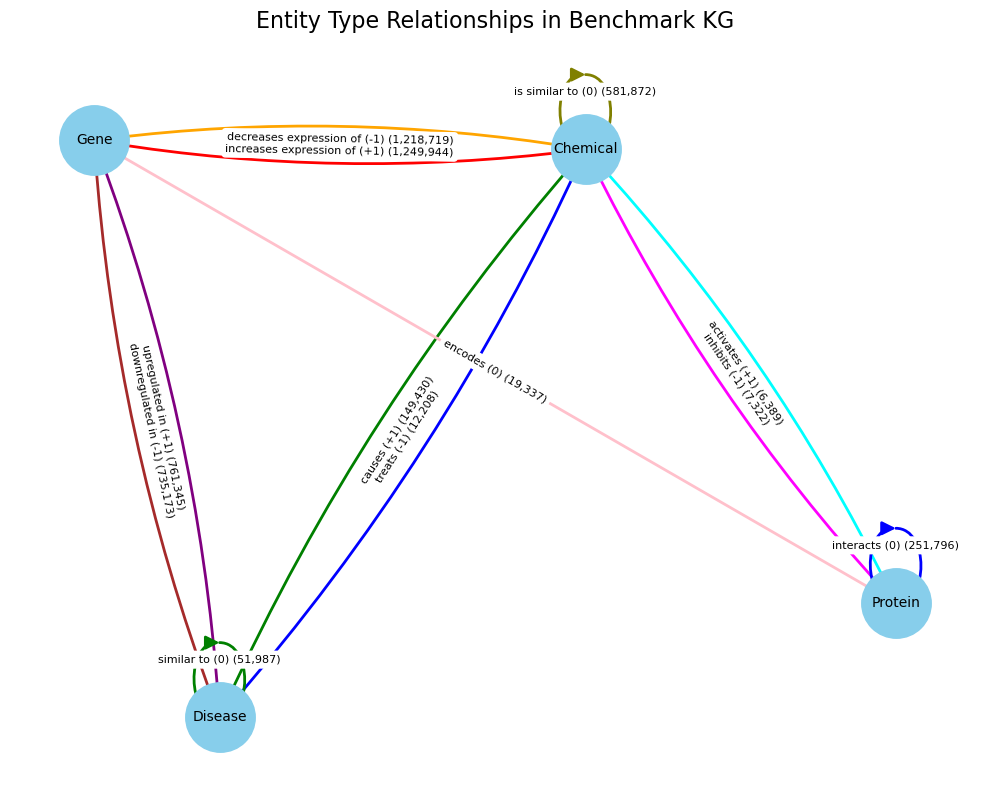

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools

# --- Data Setup ---
# Each tuple contains (source_type, target_type, relations dictionary)
data = [
    ("Chemical", "Disease", {"causes (+1)": '149,430', "treats (-1)": '12,208'}),
    ("Chemical", "Gene", {"decreases expression of (-1)": '1,218,719', "increases expression of (+1)": '1,249,944'}),  
    ("Gene", "Disease", {"upregulated in (+1)": '761,345', "downregulated in (-1)": '735,173'}),
    ("Gene", "Protein", {"encodes (0)": '19,337'}),
    ("Chemical", "Chemical", {"is similar to (0)": '581,872'}),
    ("Chemical", "Protein", {"activates (+1)": '6,389', "inhibits (-1)": '7,322'}),
    ("Protein", "Protein", {"interacts (0)": '251,796'}),
    ("Disease", "Disease", {"similar to (0)": '51,987'}),
]

# --- Create Graph ---
G = nx.MultiDiGraph()

# Add unique entity types as nodes.
nodes = set()
for source, target, _ in data:
    nodes.add(source)
    nodes.add(target)
G.add_nodes_from(nodes)

# Set up a cycle of diverse colors.
colors_list = ["blue", "green", "red", "orange", "purple", "brown", "pink", "olive", "cyan", "magenta"]
color_cycle = itertools.cycle(colors_list)
relation_colors = {}

# Add each relation as an edge with its assigned color and store its count.
for source, target, relations in data:
    for rel, count in relations.items():
        if rel not in relation_colors:
            relation_colors[rel] = next(color_cycle)
        G.add_edge(source, target, relation=rel, count=count, color=relation_colors[rel])

# --- Compute Layout ---
# Use a spring layout with an increased optimal distance (k) and more iterations.
pos = nx.spring_layout(G, k=20.0, iterations=400)

# Optional: manually adjust positions if needed.
# For example, if Chemical is still too central, you could shift it a bit:
# pos['Chemical'][0] -= 0.3  # shifts Chemical a bit to the left

# --- Draw Nodes ---
plt.figure(figsize=(10, 8))
# Increase node_size to make entity circles bigger.
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=2500)

# --- Draw Edges with Curvature to Avoid Overlap ---
# Count parallel edges between each pair.
edge_counts = {}
for u, v, key in G.edges(keys=True):
    edge_counts[(u, v)] = edge_counts.get((u, v), 0) + 1

# Draw each edge with a slight curvature.
edge_idx = {}
for u, v, key, edge_data in G.edges(keys=True, data=True):
    if (u, v) not in edge_idx:
        edge_idx[(u, v)] = 0
    total = edge_counts[(u, v)]
    # Compute curvature so that parallel edges are spread out.
    rad = 0.15 * (edge_idx[(u, v)] - (total - 1) / 2)
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        connectionstyle=f'arc3, rad = {rad}',
        edge_color=edge_data['color'],
        arrows=True,
        arrowsize=20,
        width=2
    )
    edge_idx[(u, v)] += 1

# --- Draw Node Labels ---
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')

# --- Draw Edge Labels (Relation and Count) ---
edge_labels = {}
for u, v, key, edge_data in G.edges(keys=True, data=True):
    label = f"{edge_data['relation']} ({edge_data['count']})"
    if (u, v) in edge_labels:
        edge_labels[(u, v)] += "\n" + label
    else:
        edge_labels[(u, v)] = label

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=8)

# --- Final Plot Adjustments ---
plt.title("Entity Type Relationships in Benchmark KG", fontsize=16)
plt.axis('off')
plt.tight_layout()
# Uncomment the next line to save the figure
# plt.savefig("/home/vmottaqi/kg/kg_versions/figures/benchmark_kg_schema_Apr162025.png", dpi=1000)
plt.show()


In [2]:
import numpy as np